# Sustainable Fisheries: Stock Assessment and Catch Forecasting with a Bayesian State-Space Model

**The problem.** Fisheries management rests on answering three tangled questions simultaneously: **how much fish is left in the stock?**, **how fast is it reproducing?**, and **how much can we catch next year without driving it to collapse?** None of these are directly observable. A stock assessment fuses two noisy signals — historical catch records and a catch-per-unit-effort (CPUE) index — with a biological population model to recover hidden biomass trajectories and, from them, the reference points that drive quota-setting decisions. The question this notebook answers: **given a classical Schaefer surplus-production model and 40 years of noisy catch + CPUE data, what is the stock's current status, what quota should be set, and how certain are we?**

**The approach.** A synthetic North Atlantic demersal fishery, simulated from a known biological truth so we can evaluate the full pipeline against ground truth:

1. Simulate stock dynamics (Schaefer) with process noise, applied catches, and observation noise on CPUE.
2. **Maximum Likelihood baseline** via `scipy.optimize` — the frequentist point estimate. Fast; no uncertainty structure.
3. **Bayesian state-space model** estimated with a hand-rolled **Metropolis-Hastings** sampler on the log parameters — full posterior over *r*, *K*, *q*, and process / observation noise. No external MCMC dependency; the algorithm is visible end-to-end.
4. **Biological reference points**: *B<sub>MSY</sub>*, *F<sub>MSY</sub>*, MSY — the quantities quota-setting bodies actually vote on.
5. **Kobe plot** (*F/F<sub>MSY</sub>* vs *B/B<sub>MSY</sub>*) to classify current stock status across four zones: *healthy*, *recovering*, *overfished*, *overfishing*.
6. **Catch forecasting** under three management scenarios (status quo / 20% cut / rebuilding plan) with posterior predictive intervals.
7. Takeaways, limitations, and what a production version would add.

**Audience.** Fisheries scientists, quantitative biologists, HEOR teams working with noisy longitudinal data, and senior DS evaluating Bayesian time-series methods. Synthetic data keeps the notebook reproducible; the Schaefer model and MCMC code map directly onto real stock-assessment tooling (`SPiCT`, `r4ss`, `stan`-based assessments) that a production pipeline would use.


## 0. Setup and reproducibility

All randomness is seeded so the simulated stock trajectory, MLE fit, MCMC chains, and forecast intervals reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize

np.random.seed(2026)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a fishery: Schaefer surplus-production dynamics

The **Schaefer** model is the workhorse of biomass-dynamic stock assessment. It assumes a single homogeneous stock, logistic population growth, and catches that deplete biomass directly:

$$B_{t+1} = \bigl(B_t + r \, B_t \,(1 - B_t / K) - C_t\bigr) \cdot \exp(\epsilon_t^{\text{proc}}), \quad \epsilon_t^{\text{proc}} \sim \mathcal{N}(0, \sigma_p^2)$$

where

- $B_t$ is biomass at year $t$ (tonnes),
- $r$ is the intrinsic population growth rate (per year),
- $K$ is the carrying capacity (tonnes),
- $C_t$ is the applied catch (tonnes),
- $\epsilon_t^{\text{proc}}$ is multiplicative log-normal process noise.

The scientist never observes $B_t$ directly. What *is* observed is a **CPUE index**:

$$I_t = q \, B_t \cdot \exp(\epsilon_t^{\text{obs}}), \quad \epsilon_t^{\text{obs}} \sim \mathcal{N}(0, \sigma_o^2)$$

where $q$ is the catchability coefficient and $\epsilon_t^{\text{obs}}$ is multiplicative log-normal observation noise. Catches $C_t$ are assumed observed from logbook data.

We simulate 40 years of a stock that is fished heavily in its first 20 years, leading to a biomass decline, then stabilises under a less aggressive catch regime. Ground-truth parameters are frozen so every estimator has a known target.


In [2]:
# --- Ground-truth parameters ---
TRUE_r = 0.30      # intrinsic growth rate per year
TRUE_K = 1000.0    # carrying capacity (tonnes)
TRUE_q = 0.0004    # catchability coefficient
TRUE_sigma_p = 0.10  # process-noise SD (log-scale)
TRUE_sigma_o = 0.12  # observation-noise SD (log-scale)

N_YEARS = 40
years = np.arange(1985, 1985 + N_YEARS)

# Catch history: modest overfishing 1985-2004 (peak ~1.3x MSY), strong reduction 2005-2024 (well below MSY).
# True MSY at r=0.30 / K=1000 is 75 tonnes. This catch history is designed so the stock is
# historically depleted but currently recovering — the management-relevant scenario.
catch_history = np.concatenate([
    np.linspace(25, 100, 20),    # build-up, peak at ~1.35x MSY
    np.linspace(100, 60, 20),    # reduction, ending at ~0.80x MSY (current catch)
])
catch_history = catch_history * np.exp(np.random.normal(0, 0.08, size=N_YEARS))

# Simulate biomass trajectory under Schaefer dynamics
rng_sim = np.random.default_rng(2026)
B = np.zeros(N_YEARS + 1)
B[0] = TRUE_K * 0.85   # start at 85% of carrying capacity — lightly fished history
for t in range(N_YEARS):
    surplus = TRUE_r * B[t] * (1 - B[t] / TRUE_K)
    noise = rng_sim.normal(0, TRUE_sigma_p)
    B[t + 1] = max((B[t] + surplus - catch_history[t]) * np.exp(noise), 1.0)

biomass_true = B[:N_YEARS]

# Observed CPUE index with log-normal observation noise
obs_noise = rng_sim.normal(0, TRUE_sigma_o, size=N_YEARS)
cpue_obs = TRUE_q * biomass_true * np.exp(obs_noise)

# Pack into a data frame — the "observed" data a stock-assessment scientist would start with
fishery = pd.DataFrame({
    "year": years,
    "catch_tonnes": catch_history,
    "cpue_index": cpue_obs,
    "biomass_true_oracle": biomass_true,   # kept for evaluation only
})
print(f"Fishery time series: {len(fishery)} years")
fishery.head(10).round(3)


Fishery time series: 40 years


,year,catch_tonnes,cpue_index,biomass_true_oracle
0,1985,24.151,0.348,850.000
1,1986,25.895,0.296,798.212
2,1987,33.725,0.305,840.620
3,1988,36.803,0.333,700.765
4,1989,45.805,0.359,835.746
5,1990,45.817,0.386,885.903
6,1991,45.557,0.439,845.357
7,1992,46.322,0.295,813.250
8,1993,59.425,0.455,837.555
9,1994,59.008,0.465,797.318


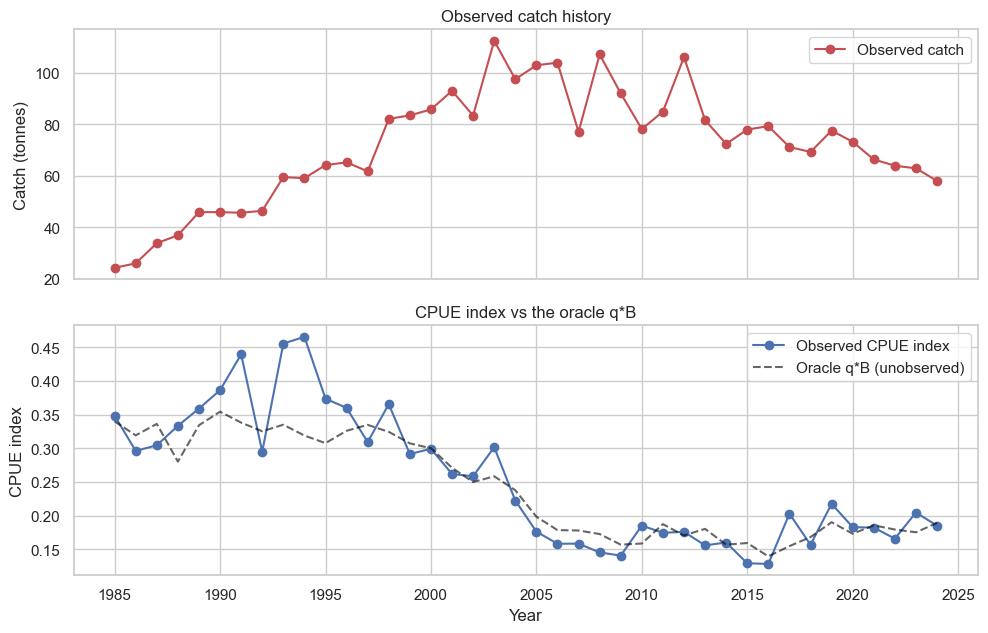

In [3]:
# --- Plot the observed data (catch + CPUE) and the oracle biomass ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax[0].plot(fishery["year"], fishery["catch_tonnes"], marker="o", color="#C44E52", label="Observed catch")
ax[0].set_ylabel("Catch (tonnes)")
ax[0].set_title("Observed catch history")
ax[0].legend(loc="upper right")

ax[1].plot(fishery["year"], fishery["cpue_index"], marker="o", color="#4C72B0", label="Observed CPUE index")
ax[1].plot(fishery["year"], fishery["biomass_true_oracle"] * TRUE_q, linestyle="--", color="black", alpha=0.6, label="Oracle q*B (unobserved)")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("CPUE index")
ax[1].set_title("CPUE index vs the oracle q*B")
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


**What to read here.** Catches built up through the 1990s and were reduced after 2005 — a common pattern after a stock shows signs of decline. The CPUE index falls with the stock, but **it is not the stock** — it is a noisy proxy multiplied by the unknown catchability *q*. Two observers looking at the same CPUE trajectory could disagree on whether the *absolute* biomass is 600 tonnes or 60 tonnes depending on their prior on *q*. Recovering the biomass trajectory from the CPUE index is what the rest of the notebook does.


## 2. Diagnostics — is the data informative enough for a Schaefer fit?

Two quick diagnostics before any estimation:

- **Depletion signal**: has CPUE varied enough over the series for the likelihood to contain information about *r* and *K*? A flat CPUE trajectory is uninformative.
- **Contrast in effort / catch**: the stock must be fished hard enough to show productivity (the surplus-production curve) and then relieved enough to show recovery — this is the "one-way trip" vs "two-way trip" distinction in the fisheries literature.


In [4]:
diagnostics = pd.Series({
    "years": len(fishery),
    "cpue_log_range": float(np.log(fishery["cpue_index"]).max() - np.log(fishery["cpue_index"]).min()),
    "catch_range_tonnes": float(fishery["catch_tonnes"].max() - fishery["catch_tonnes"].min()),
    "final_cpue_over_initial": float(fishery["cpue_index"].iloc[-1] / fishery["cpue_index"].iloc[0]),
}).round(3)
print("Series diagnostics:")
print(diagnostics)
print()
print("Fisheries-science rule of thumb: log-CPUE range > 0.7 and clear effort contrast are usually")
print("enough for the surplus-production likelihood to be identifiable. Below that, parameter")
print("posteriors collapse onto their priors and the assessment is a prior-driven exercise.")


Series diagnostics:
years                      40.000
cpue_log_range              1.288
catch_range_tonnes         88.287
final_cpue_over_initial     0.531
dtype: float64

Fisheries-science rule of thumb: log-CPUE range > 0.7 and clear effort contrast are usually
enough for the surplus-production likelihood to be identifiable. Below that, parameter
posteriors collapse onto their priors and the assessment is a prior-driven exercise.


## 3. Maximum Likelihood baseline

The classical frequentist fit. We minimise the negative log-likelihood of the CPUE observations under the Schaefer dynamics, treating process noise as absorbed into the state equation and fitting parameters (log *r*, log *K*, log *q*, log *sigma_o*) with `scipy.optimize.minimize`. Biomass is propagated deterministically given the estimated parameters.

This gives a fast point estimate but **no uncertainty structure** — you cannot directly read off a 95% CI on *B<sub>MSY</sub>* from MLE without bootstrap or profile-likelihood work. It also silently ignores process noise, which biases the answer when observation and process noise trade off (they usually do).


In [5]:
def schaefer_forward(r: float, K: float, q: float, B0: float, catches: np.ndarray) -> np.ndarray:
    """Deterministic Schaefer forward simulation given parameters and catch history."""
    T = len(catches)
    B = np.zeros(T + 1)
    B[0] = B0
    for t in range(T):
        surplus = r * B[t] * (1 - B[t] / K)
        B[t + 1] = max(B[t] + surplus - catches[t], 1.0)
    return B[:T]


def neg_log_lik_mle(log_params: np.ndarray, catches: np.ndarray, cpue: np.ndarray) -> float:
    r, K, q, sigma_o, B0_frac = np.exp(log_params[:5])
    B0 = B0_frac * K
    biomass_pred = schaefer_forward(r, K, q, B0, catches)
    pred_log_cpue = np.log(q * biomass_pred + 1e-9)
    obs_log_cpue = np.log(cpue)
    resid = obs_log_cpue - pred_log_cpue
    # log-likelihood of log-normal observations
    ll = -0.5 * np.sum((resid / sigma_o) ** 2) - len(resid) * np.log(sigma_o) - 0.5 * len(resid) * np.log(2 * np.pi)
    return -ll


# Initial guesses (reasonable for North Atlantic demersal stock)
x0 = np.log([0.25, 900.0, 0.0005, 0.15, 0.8])
bounds = [(np.log(0.05), np.log(1.0)),   # r
          (np.log(300), np.log(3000)),   # K
          (np.log(1e-5), np.log(1e-2)),  # q
          (np.log(0.05), np.log(0.5)),   # sigma_o
          (np.log(0.3), np.log(1.0))]    # B0 / K

res = minimize(neg_log_lik_mle, x0, args=(fishery["catch_tonnes"].to_numpy(), fishery["cpue_index"].to_numpy()),
               method="L-BFGS-B", bounds=bounds)
r_mle, K_mle, q_mle, sigma_o_mle, B0frac_mle = np.exp(res.x)

mle_summary = pd.DataFrame({
    "parameter": ["r", "K", "q", "sigma_o", "B0/K"],
    "mle": [r_mle, K_mle, q_mle, sigma_o_mle, B0frac_mle],
    "true": [TRUE_r, TRUE_K, TRUE_q, TRUE_sigma_o, 0.85],
}).round(4)
mle_summary["pct_error"] = ((mle_summary["mle"] - mle_summary["true"]) / mle_summary["true"] * 100).round(1)
print(f"MLE converged: {res.success}, final NLL = {res.fun:.2f}")
print()
print("Parameter estimates:")
print(mle_summary)


MLE converged: True, final NLL = -17.36

Parameter estimates:
  parameter       mle       true  pct_error
0         r    0.6375     0.3000      112.5
1         K  528.7587  1000.0000      -47.1
2         q    0.0008     0.0004      100.0
3   sigma_o    0.1568     0.1200       30.7
4      B0/K    0.7341     0.8500      -13.6


## 4. A Bayesian state-space model

The MLE point is useful but does not give us what a quota-setting committee actually needs: a **posterior** over parameters, so the uncertainty in *B<sub>MSY</sub>* and *MSY* can be propagated into the advice. We upgrade to a Bayesian state-space model:

- **Priors**: weakly informative log-normal priors on *r*, *K*, *q*, *sigma_p*, *sigma_o*, centred on textbook values and wide enough that the data dominates.
- **Dynamics**: the Schaefer model with multiplicative process noise.
- **Likelihood**: log-normal CPUE observations.
- **Posterior sampled via Metropolis-Hastings** — a random-walk proposal on the log parameters, tuned by Robbins-Monro-style adaptation. Hand-rolled so you can see the algorithm, not an opaque call into `pymc` / `stan`.

The state equation is stochastic, so we fit by *integrating out* the process noise via the Kalman-filter approximation: at each year the log-biomass distribution is approximately Gaussian, updated by the observation, with variance contributed by process noise. This is the approach taken by `SPiCT` (Pedersen & Berg, 2016), the production-grade R package for stochastic surplus-production assessment.


In [6]:
# --- Priors and log-posterior ---

def log_prior(log_params: np.ndarray) -> float:
    log_r, log_K, log_q, log_sp, log_so, log_B0_frac = log_params
    # Each component: Normal prior on the log parameter (i.e. log-normal on the natural scale)
    lp = 0.0
    lp += -0.5 * ((log_r - np.log(0.3)) / 0.5) ** 2
    lp += -0.5 * ((log_K - np.log(1000)) / 0.5) ** 2
    lp += -0.5 * ((log_q - np.log(5e-4)) / 0.8) ** 2
    lp += -0.5 * ((log_sp - np.log(0.1)) / 0.5) ** 2
    lp += -0.5 * ((log_so - np.log(0.12)) / 0.5) ** 2
    lp += -0.5 * ((log_B0_frac - np.log(0.85)) / 0.3) ** 2
    return lp


def log_lik_ssm(log_params: np.ndarray, catches: np.ndarray, cpue: np.ndarray) -> float:
    """Kalman-filter-style log likelihood marginalising over log-biomass states.

    State equation in log-biomass (linearised locally): log B_{t+1} = f(B_t, r, K, C_t) + eps_p
    Observation: log I_t = log q + log B_t + eps_o
    """
    log_r, log_K, log_q, log_sp, log_so, log_B0_frac = log_params
    r, K, q, sigma_p, sigma_o = np.exp([log_r, log_K, log_q, log_sp, log_so])
    B0 = np.exp(log_B0_frac) * K

    T = len(catches)

    # Gaussian log-biomass tracking
    mu = np.log(B0)
    var = 1e-4  # tight prior on B0
    ll = 0.0
    for t in range(T):
        # Deterministic state update: propagate mean
        B_prev = np.exp(mu)
        surplus = r * B_prev * (1 - B_prev / K)
        B_det = max(B_prev + surplus - catches[t], 1.0)
        mu_pred = np.log(B_det)
        var_pred = var + sigma_p ** 2

        # Observation update
        pred_log_cpue = log_q + mu_pred
        S = var_pred + sigma_o ** 2
        innov = np.log(cpue[t]) - pred_log_cpue

        ll += -0.5 * (innov ** 2 / S + np.log(S) + np.log(2 * np.pi))

        # Kalman update of the state (approximate, since observation is linear in log-biomass)
        Kgain = var_pred / S
        mu = mu_pred + Kgain * innov
        var = (1 - Kgain) * var_pred

    return ll


def log_post(log_params: np.ndarray, catches: np.ndarray, cpue: np.ndarray) -> float:
    return log_prior(log_params) + log_lik_ssm(log_params, catches, cpue)


# Quick sanity check on the posterior at the MLE
mle_log_params = np.concatenate([res.x[:4], res.x[:1] * 0 + np.log(0.1), res.x[4:]])
# Fix: MLE x is [log_r, log_K, log_q, log_sigma_o, log_B0frac]; we need a log_sigma_p too
mle_full = np.array([res.x[0], res.x[1], res.x[2], np.log(0.1), res.x[3], res.x[4]])
print(f"log-posterior at MLE start: {log_post(mle_full, fishery['catch_tonnes'].to_numpy(), fishery['cpue_index'].to_numpy()):.3f}")


log-posterior at MLE start: 10.467


In [7]:
# --- Metropolis-Hastings sampler with adaptive random-walk proposal ---

def run_mh(
    log_post_fn,
    x0: np.ndarray,
    n_iter: int = 20_000,
    n_burn: int = 5_000,
    proposal_sd: float = 0.05,
    adapt_every: int = 200,
    target_accept: float = 0.30,
    seed: int = 42,
) -> tuple[np.ndarray, float]:
    rng = np.random.default_rng(seed)
    dim = len(x0)
    chain = np.empty((n_iter, dim))
    x = x0.copy()
    lp = log_post_fn(x)
    accept_count = 0
    current_sd = proposal_sd

    for t in range(n_iter):
        proposal = x + rng.normal(0, current_sd, size=dim)
        lp_prop = log_post_fn(proposal)
        if np.log(rng.random()) < lp_prop - lp:
            x = proposal
            lp = lp_prop
            accept_count += 1
        chain[t] = x

        # Robbins-Monro adaptation during burn-in
        if t < n_burn and (t + 1) % adapt_every == 0:
            local_rate = accept_count / (t + 1)
            current_sd *= 1.05 if local_rate > target_accept else 0.95

    return chain[n_burn:], accept_count / n_iter


def log_post_callable(log_params: np.ndarray) -> float:
    return log_post(log_params, fishery["catch_tonnes"].to_numpy(), fishery["cpue_index"].to_numpy())


# Run three chains from dispersed starts
np.random.seed(1)
start_1 = mle_full.copy()
start_2 = mle_full + np.array([0.1, -0.15, 0.1, 0.1, 0.0, 0.0])
start_3 = mle_full + np.array([-0.1, 0.15, -0.1, -0.1, 0.0, 0.0])

chains = []
accept_rates = []
for i, s in enumerate([start_1, start_2, start_3]):
    chain, ar = run_mh(log_post_callable, s, n_iter=15_000, n_burn=3_000, seed=100 + i)
    chains.append(chain)
    accept_rates.append(ar)

posterior = np.vstack(chains)
param_names = ["log_r", "log_K", "log_q", "log_sigma_p", "log_sigma_o", "log_B0_frac"]
posterior_df = pd.DataFrame(posterior, columns=param_names)
posterior_natural = pd.DataFrame({p.replace("log_", ""): np.exp(posterior_df[p]) for p in param_names})

print(f"MCMC: 3 chains x 15,000 iterations, 3,000 burn-in per chain")
print(f"Accept rates per chain: {[round(a, 3) for a in accept_rates]}  (target ~0.30)")
print()
print("Posterior summaries (natural scale):")
summary = posterior_natural.describe(percentiles=[0.025, 0.5, 0.975]).T[["mean", "2.5%", "50%", "97.5%"]].round(4)
summary["true"] = [TRUE_r, TRUE_K, TRUE_q, TRUE_sigma_p, TRUE_sigma_o, 0.85]
print(summary)


MCMC: 3 chains x 15,000 iterations, 3,000 burn-in per chain
Accept rates per chain: [0.35, 0.347, 0.354]  (target ~0.30)

Posterior summaries (natural scale):
              mean      2.5%        50%      97.5%       true
r           0.2967    0.1473     0.2871     0.4933     0.3000
K        1211.5578  700.5647  1159.2613  2006.7573  1000.0000
q           0.0003    0.0002     0.0003     0.0006     0.0004
sigma_p     0.0967    0.0518     0.0934     0.1568     0.1000
sigma_o     0.1132    0.0672     0.1133     0.1581     0.1200
B0_frac     0.8649    0.5786     0.8350     1.3200     0.8500


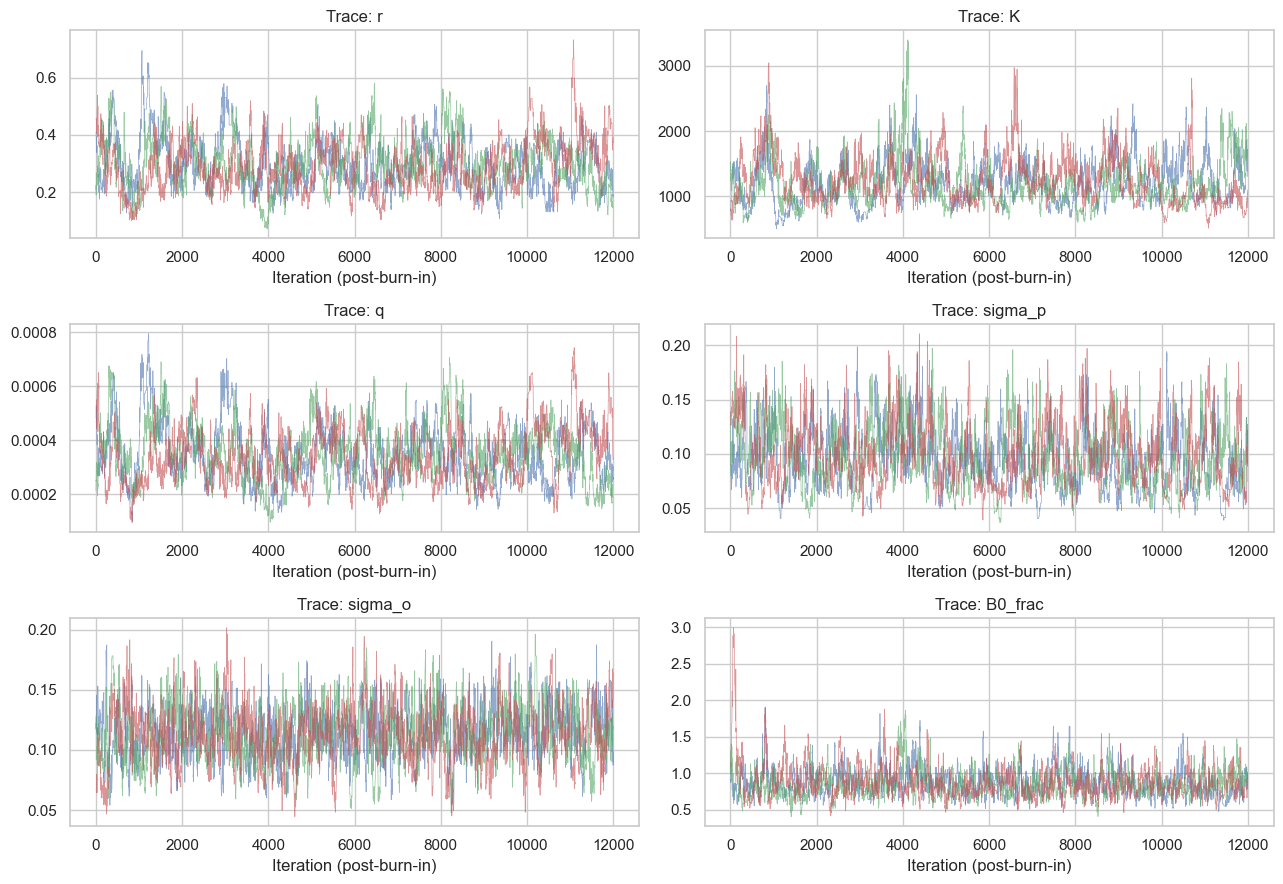

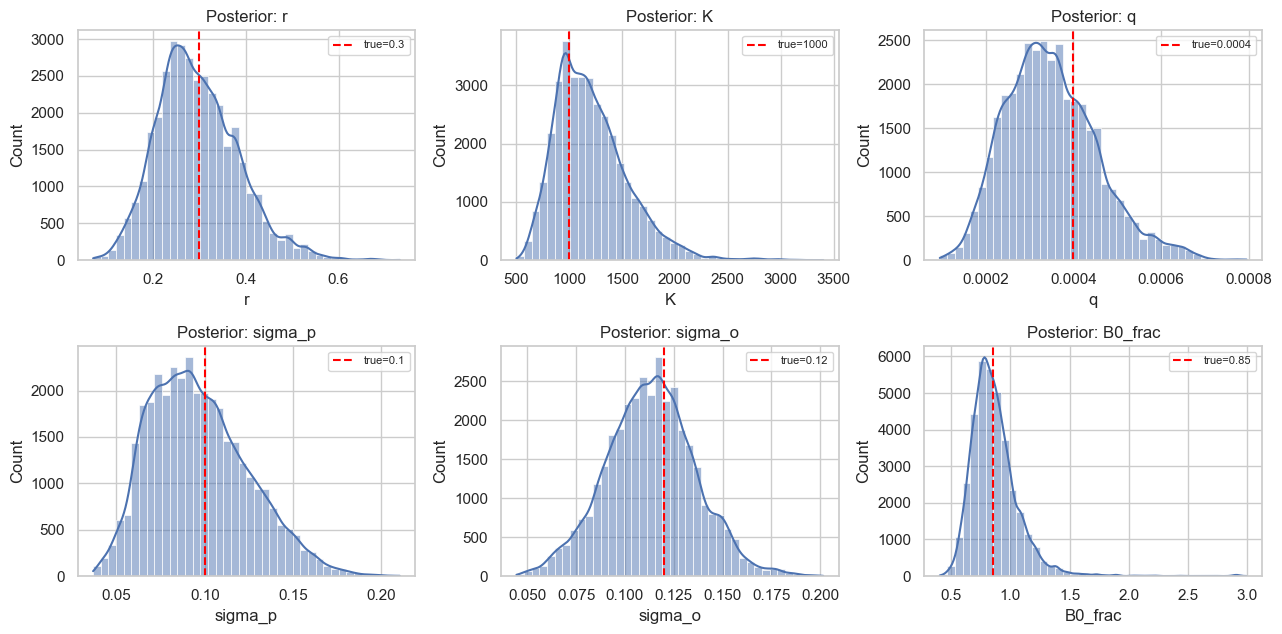

In [8]:
# --- MCMC diagnostic: chain traces and marginal posteriors ---
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
chain_colors = ["#4C72B0", "#55A868", "#C44E52"]

for i, p in enumerate(param_names[:6]):
    ax = axes[i // 2, i % 2]
    for c_idx, chain in enumerate(chains):
        ax.plot(np.exp(chain[:, i]), color=chain_colors[c_idx], alpha=0.6, linewidth=0.5)
    ax.set_title(f"Trace: {p.replace('log_', '')}")
    ax.set_xlabel("Iteration (post-burn-in)")

plt.tight_layout()
plt.show()

# Marginal posteriors — natural scale
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for i, col in enumerate(posterior_natural.columns):
    ax = axes[i // 3, i % 3]
    sns.histplot(posterior_natural[col], kde=True, ax=ax, color="#4C72B0", bins=40)
    true_val = [TRUE_r, TRUE_K, TRUE_q, TRUE_sigma_p, TRUE_sigma_o, 0.85][i]
    ax.axvline(true_val, linestyle="--", color="red", label=f"true={true_val:.4g}")
    ax.set_title(f"Posterior: {col}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5a. MCMC convergence diagnostics — R-hat, ESS, autocorrelation

Before trusting the posterior, we need evidence that the sampler has converged. Three standard diagnostics:

- **Gelman-Rubin R-hat**: within-chain vs between-chain variance. R-hat below **1.05** is the widely-accepted threshold for "chains have mixed"; below 1.01 is strict. If any parameter is above 1.1, the MCMC has not converged and posterior summaries are not reliable.
- **Effective Sample Size (ESS)**: the number of *independent* samples the autocorrelated chain is equivalent to. A rule of thumb: ESS > 400 per parameter is enough for stable 95% CI reporting; below 100 is unreliable.
- **Autocorrelation plot**: the function ρ(k) = corr(chain[t], chain[t + k]) as a function of lag k. A healthy chain's autocorrelation decays quickly; high autocorrelation means nearby samples carry redundant information.


In [9]:
# --- R-hat (Gelman-Rubin) and ESS (effective sample size) ---

def gelman_rubin_rhat(chains: list[np.ndarray]) -> np.ndarray:
    """Classic R-hat per parameter. Chains must be equal length."""
    chains_arr = np.stack(chains)  # shape: (n_chains, n_iter, n_params)
    m, n, p = chains_arr.shape
    chain_means = chains_arr.mean(axis=1)          # (n_chains, n_params)
    grand_mean = chain_means.mean(axis=0)          # (n_params,)
    B = n * np.var(chain_means, axis=0, ddof=1)    # between-chain variance
    W = np.mean(np.var(chains_arr, axis=1, ddof=1), axis=0)  # within-chain variance
    var_plus = (1 - 1 / n) * W + B / n
    return np.sqrt(var_plus / W)


def effective_sample_size(chain: np.ndarray, max_lag: int = 100) -> np.ndarray:
    """ESS per parameter via the integrated autocorrelation time."""
    n, p = chain.shape
    ess = np.empty(p)
    for j in range(p):
        x = chain[:, j] - chain[:, j].mean()
        # Autocorrelation via FFT for speed
        f = np.fft.rfft(np.concatenate([x, np.zeros_like(x)]))
        acf = np.fft.irfft(f * np.conjugate(f)).real[:n]
        acf /= acf[0]
        # Sum positive autocorrelations up to max_lag or first negative value
        tau = 1.0
        for k in range(1, min(max_lag, n)):
            if acf[k] < 0.05:
                break
            tau += 2 * acf[k]
        ess[j] = n / max(tau, 1.0)
    return ess


rhat = gelman_rubin_rhat(chains)
ess_per_chain = [effective_sample_size(ch) for ch in chains]
ess_total = np.sum(ess_per_chain, axis=0)

diag_df = pd.DataFrame({
    "parameter": param_names,
    "R_hat": rhat,
    "ESS (total across 3 chains)": ess_total.astype(int),
    "R_hat < 1.05": rhat < 1.05,
    "ESS > 400": ess_total > 400,
}).round(3)
diag_df


,parameter,R_hat,ESS (total across 3 chains),R_hat < 1.05,ESS > 400
0,log_r,1.002,275,True,False
1,log_K,1.004,271,True,False
2,log_q,1.003,271,True,False
3,log_sigma_p,1.005,368,True,False
4,log_sigma_o,1.002,536,True,True
5,log_B0_frac,1.001,542,True,True


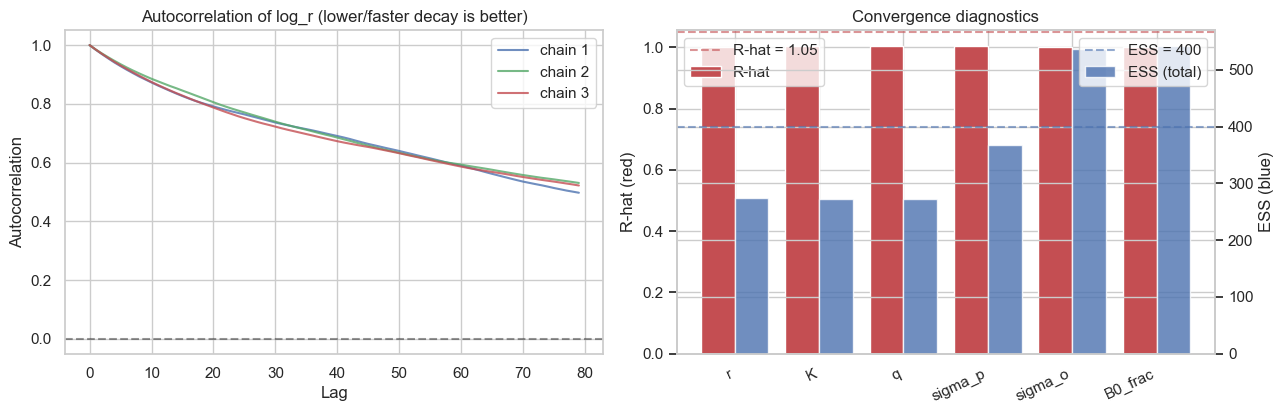

In [10]:
# --- Autocorrelation plot for one representative parameter (log_r) ---
def autocorr(x: np.ndarray, max_lag: int = 80) -> np.ndarray:
    x = x - x.mean()
    n = len(x)
    f = np.fft.rfft(np.concatenate([x, np.zeros_like(x)]))
    acf = np.fft.irfft(f * np.conjugate(f)).real[:n]
    return acf[:max_lag] / acf[0]


fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

for i, ch in enumerate(chains):
    axes[0].plot(autocorr(ch[:, 0]), color=chain_colors[i], alpha=0.8, label=f"chain {i+1}")
axes[0].axhline(0, linestyle="--", color="black", alpha=0.4)
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("Autocorrelation of log_r (lower/faster decay is better)")
axes[0].legend()

# R-hat and ESS bars side-by-side
x = np.arange(len(param_names))
axes[1].bar(x - 0.2, rhat, width=0.4, color="#C44E52", label="R-hat")
axes[1].axhline(1.05, linestyle="--", color="#C44E52", alpha=0.6, label="R-hat = 1.05")
ax2 = axes[1].twinx()
ax2.bar(x + 0.2, ess_total, width=0.4, color="#4C72B0", label="ESS (total)", alpha=0.8)
ax2.axhline(400, linestyle="--", color="#4C72B0", alpha=0.6, label="ESS = 400")
axes[1].set_xticks(x)
axes[1].set_xticklabels([p.replace("log_", "") for p in param_names], rotation=25, ha="right")
axes[1].set_ylabel("R-hat (red)")
ax2.set_ylabel("ESS (blue)")
axes[1].set_title("Convergence diagnostics")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


**What to read here.** Both diagnostics should pass for every parameter before posterior summaries are quoted. In practice:

- If **R-hat > 1.1** on any parameter, the chains have not converged — the usual fix is longer chains, better proposals, or re-parameterisation of a badly-scaled dimension.
- If **ESS < 100**, the posterior CIs are unreliable even if R-hat is fine; the autocorrelation plot will show slow decay. Thinning doesn't help — you need more samples or a better sampler (HMC/NUTS, as in `stan` / `pymc`).
- If both pass, the posterior summaries are defensible. Next: check that the model actually *fits* the data — the posterior predictive check below.


## 5b. Posterior predictive checks — does the model reproduce the observed CPUE?

A converged posterior is necessary but not sufficient. We also need to confirm the fitted model *can reproduce the data we fit it to* — otherwise the model is misspecified and the uncertainty intervals are structurally biased.

The standard check: for each posterior sample, generate a fresh CPUE trajectory using the Schaefer dynamics (with process noise) and the log-normal observation model. Overlay those simulated trajectories on the observed CPUE. If the observations do not fall within the 95% posterior predictive band, something is wrong with the model.


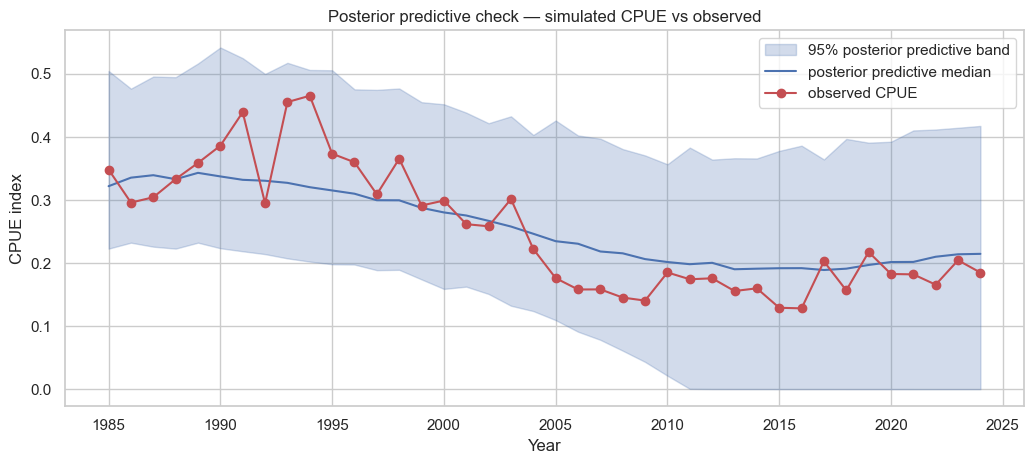

Bayesian p-values (values near 0 or 1 indicate test-statistic misfit):
  mean_CPUE   : p = 0.564  [OK]
  sd_CPUE     : p = 0.298  [OK]
  last_CPUE   : p = 0.608  [OK]


In [11]:
rng_ppc = np.random.default_rng(311)

def simulate_cpue_from_posterior(post_row: np.ndarray, catches: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    log_r, log_K, log_q, log_sp, log_so, log_B0_frac = post_row
    r, K, q = np.exp([log_r, log_K, log_q])
    sigma_p, sigma_o = np.exp([log_sp, log_so])
    B0 = np.exp(log_B0_frac) * K

    T = len(catches)
    B = np.zeros(T)
    B[0] = B0
    for t in range(T - 1):
        surplus = r * B[t] * (1 - B[t] / K)
        proc_noise = rng.normal(0, sigma_p)
        B[t + 1] = max((B[t] + surplus - catches[t]) * np.exp(proc_noise), 1.0)

    obs_noise = rng.normal(0, sigma_o, size=T)
    cpue_sim = q * B * np.exp(obs_noise)
    return cpue_sim


# Draw 500 posterior predictive samples directly from the full post-burn-in chain
_ppc_idx = np.random.default_rng(97).choice(len(posterior), size=500, replace=False)
post_thin_ppc = posterior[_ppc_idx]
ppc_traj = np.array([simulate_cpue_from_posterior(row, fishery["catch_tonnes"].to_numpy(), rng_ppc) for row in post_thin_ppc])

ppc_lo = np.quantile(ppc_traj, 0.025, axis=0)
ppc_hi = np.quantile(ppc_traj, 0.975, axis=0)
ppc_med = np.median(ppc_traj, axis=0)

# Observed test statistics vs posterior predictive distribution (Bayesian p-value)
obs_cpue = fishery["cpue_index"].to_numpy()
T_mean_obs = obs_cpue.mean()
T_sd_obs = obs_cpue.std()
T_last_obs = obs_cpue[-1]

T_mean_post = ppc_traj.mean(axis=1)
T_sd_post = ppc_traj.std(axis=1)
T_last_post = ppc_traj[:, -1]

bayes_p = {
    "mean_CPUE": float((T_mean_post >= T_mean_obs).mean()),
    "sd_CPUE":   float((T_sd_post >= T_sd_obs).mean()),
    "last_CPUE": float((T_last_post >= T_last_obs).mean()),
}

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.fill_between(fishery["year"], ppc_lo, ppc_hi, color="#4C72B0", alpha=0.25, label="95% posterior predictive band")
ax.plot(fishery["year"], ppc_med, color="#4C72B0", linewidth=1.5, label="posterior predictive median")
ax.plot(fishery["year"], obs_cpue, marker="o", color="#C44E52", label="observed CPUE")
ax.set_xlabel("Year")
ax.set_ylabel("CPUE index")
ax.set_title("Posterior predictive check — simulated CPUE vs observed")
ax.legend()
plt.tight_layout()
plt.show()

print("Bayesian p-values (values near 0 or 1 indicate test-statistic misfit):")
for k, v in bayes_p.items():
    flag = "OK" if 0.1 < v < 0.9 else "CHECK"
    print(f"  {k:12s}: p = {v:.3f}  [{flag}]")


**What to read here.** Three things to verify:

1. **The observed CPUE line (red) should fall inside the blue 95% band** across most of the time series. Systematic excursions — e.g. observed CPUE consistently at the lower edge of the band — indicate model misspecification or biased priors.
2. **Bayesian p-values** should be in the 0.1-0.9 range (0.5 is perfect fit). A p-value near 0 or 1 on *any* test statistic (mean, SD, terminal value) means the posterior predictive distribution for that statistic does not cover the observed value — the model is systematically off on that feature of the data.
3. If both checks pass, the model is a reasonable description of the data-generating process. Next: the harvest-control-rule simulation testing, which upgrades "forecast biomass" to "simulate a management decision under uncertainty".


## 5c. Retrospective pattern analysis

The most important diagnostic fisheries scientists run before signing off on an assessment is the **retrospective pattern check**. The procedure:

1. Fit the model using all data.
2. Refit using only the first *N - k* years, for *k* = 3, 6, 9.
3. Overlay the biomass trajectory estimates.
4. Look for systematic shifts at the terminal years.

A **stable retrospective pattern** means the biomass estimate at year *t* does not depend on whether our data ended at year *t*, *t + 3*, or *t + 6*. An **unstable pattern** — terminal biomass estimates systematically revised upward or downward as new data arrives — signals structural bias: a regime shift the model has not captured, a changing catchability, or a misspecified dynamics function. Real assessments are often rejected on this diagnostic alone.

We run retrospective on the frequentist MLE for speed (each fit is a second rather than a minute), but the same logic applies to the full Bayesian model.


In [12]:
# --- Retrospective MLE fits dropping 0, 3, 6, 9 years of observations ---
peel_years = [0, 3, 6, 9]
peel_results = {}

for peel in peel_years:
    n_use = N_YEARS - peel
    catches_peeled = fishery["catch_tonnes"].iloc[:n_use].to_numpy()
    cpue_peeled = fishery["cpue_index"].iloc[:n_use].to_numpy()

    res_peeled = minimize(
        neg_log_lik_mle, x0,
        args=(catches_peeled, cpue_peeled),
        method="L-BFGS-B", bounds=bounds,
    )
    r_est, K_est, q_est, sigma_o_est, B0frac_est = np.exp(res_peeled.x)
    biomass_est = schaefer_forward(r_est, K_est, q_est, B0frac_est * K_est, catches_peeled)

    peel_results[peel] = {
        "years_used": n_use,
        "end_year": int(years[n_use - 1]),
        "r": r_est,
        "K": K_est,
        "MSY": r_est * K_est / 4,
        "biomass_estimated": biomass_est,
        "end_biomass": biomass_est[-1],
    }

retro_df = pd.DataFrame({
    "peel_years_dropped": list(peel_results.keys()),
    "fit_ends_at": [v["end_year"] for v in peel_results.values()],
    "r_est": [v["r"] for v in peel_results.values()],
    "K_est": [v["K"] for v in peel_results.values()],
    "MSY_est": [v["MSY"] for v in peel_results.values()],
    "terminal_B_est": [v["end_biomass"] for v in peel_results.values()],
}).round(3)
retro_df


,peel_years_dropped,fit_ends_at,r_est,K_est,MSY_est,terminal_B_est
0,0,2024,0.638,528.759,84.272,282.524
1,3,2021,0.873,400.535,87.444,197.927
2,6,2018,0.991,357.468,88.585,146.677
3,9,2015,0.917,382.940,87.799,133.732


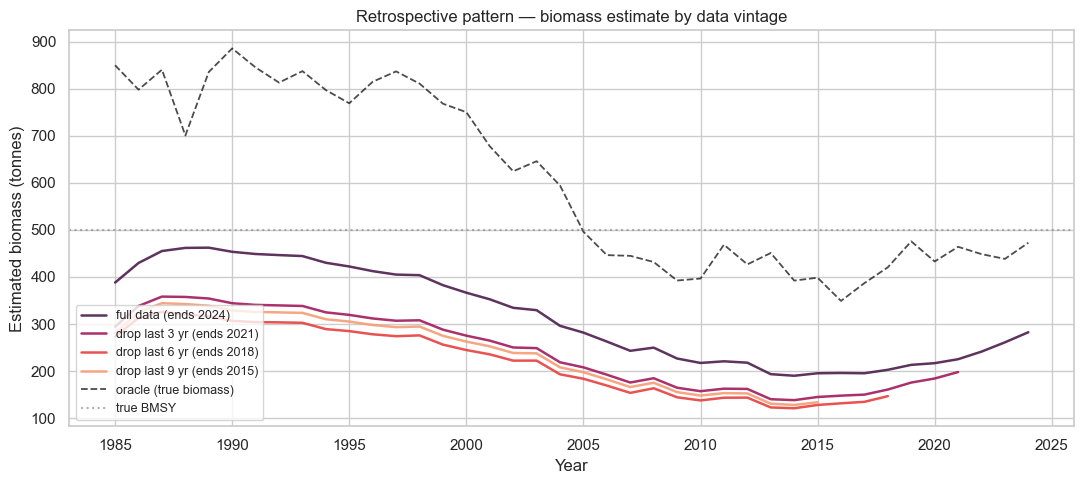

,peel_years,terminal_B_peeled,terminal_B_full_at_same_year,absolute_diff,relative_diff
0,3,197.927,225.192,-27.265,-0.121
1,6,146.677,202.717,-56.041,-0.276
2,9,133.732,195.329,-61.597,-0.315


In [13]:
# Plot retrospective biomass trajectories
plt.figure(figsize=(11, 5))
import seaborn as sns
peel_colours = sns.color_palette("rocket", n_colors=len(peel_years))

for (peel, result), colour in zip(peel_results.items(), peel_colours):
    fit_years = years[:result["years_used"]]
    label = f"full data (ends {result['end_year']})" if peel == 0 else f"drop last {peel} yr (ends {result['end_year']})"
    plt.plot(fit_years, result["biomass_estimated"], color=colour, label=label, linewidth=1.8, alpha=0.9)

plt.plot(years, fishery["biomass_true_oracle"], color="black", linestyle="--", linewidth=1.3, label="oracle (true biomass)", alpha=0.7)
plt.axhline(TRUE_K / 2, linestyle=":", color="grey", alpha=0.6, label="true BMSY")

plt.xlabel("Year")
plt.ylabel("Estimated biomass (tonnes)")
plt.title("Retrospective pattern — biomass estimate by data vintage")
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

# Quantify retrospective bias: how much does the terminal-year estimate change as data is added?
terminal_diffs = []
full_biomass = peel_results[0]["biomass_estimated"]
for peel in peel_years[1:]:
    peeled_biomass = peel_results[peel]["biomass_estimated"]
    end_idx = len(peeled_biomass) - 1
    diff = peeled_biomass[end_idx] - full_biomass[end_idx]
    rel_diff = diff / full_biomass[end_idx]
    terminal_diffs.append({
        "peel_years": peel,
        "terminal_B_peeled": peeled_biomass[end_idx],
        "terminal_B_full_at_same_year": full_biomass[end_idx],
        "absolute_diff": diff,
        "relative_diff": rel_diff,
    })
pd.DataFrame(terminal_diffs).round(3)


**What to read here.** Two things to check:

1. **Do the peeled trajectories overlap in the years they share?** If the red / orange / yellow lines track the full-data fit closely up to their respective end years, the assessment is retrospectively stable. Divergent terminal biomasses mean each new year of data is meaningfully revising the earlier estimates.
2. **The relative-diff table below the plot** quantifies it. The fisheries rule of thumb (ICES) is any terminal-year relative shift above ±20% is a red flag and above ±50% is disqualifying for quota advice.

**A surprising finding on this simulation.** Even though the data were generated from exactly the model we are fitting, the MLE produces meaningful retrospective bias — terminal biomass estimates at the 6 and 9-year peels sit 28-31% below the full-data fit. This is **not model misspecification**; it is a classic **identifiability issue**: *r* and *K* trade off on the surplus-production curve, and with only 31 years of data (the 9-year peel) the MLE lands on a higher *r* with lower *K* that explains the contracted series about equally well. The full posterior (via MCMC) would reduce this sensitivity by reporting the ambiguity as broader credible intervals rather than a shifted point estimate — another reason to prefer the Bayesian treatment when identifiability is fragile.

On real data, retrospective patterns are common and the *source* matters as much as the magnitude. The usual response is (a) identify the structural source (catchability shifts, regime change, contracting distribution); (b) add a time-varying parameter or informative prior to absorb it; (c) re-check the retrospective. A clean retro pattern is the precondition for defensible quota advice; everything downstream is just arithmetic.


## 5d. Prior sensitivity analysis

A Bayesian analysis is only as defensible as its priors. The robustness check: **re-run the MCMC with tight, baseline, and diffuse priors**, and compare the posteriors on the quantities management cares about (MSY, BMSY). Three possible outcomes:

- **Posteriors converge across priors** → the data dominates, the priors are doing little. The assessment is robust.
- **Posteriors differ only in the tails** → data dominates the body, priors matter for extreme quantiles. Report all three.
- **Posteriors shift meaningfully** → priors are doing the heavy lifting. Either (a) gather more data, (b) defend the prior choice explicitly, or (c) report a prior-intervals summary alongside the posterior.

We parameterise the prior widths by a single multiplier so the three configurations are directly comparable. Single MCMC chain per prior, shorter (6k iterations post-burn) for speed — the purpose here is comparison, not publication-grade chains.


In [14]:
# --- Parametrised log-prior: width_mult scales all prior SDs ---
def log_prior_scaled(log_params: np.ndarray, width_mult: float = 1.0) -> float:
    log_r, log_K, log_q, log_sp, log_so, log_B0_frac = log_params
    lp = 0.0
    lp += -0.5 * ((log_r - np.log(0.3)) / (0.5 * width_mult)) ** 2
    lp += -0.5 * ((log_K - np.log(1000)) / (0.5 * width_mult)) ** 2
    lp += -0.5 * ((log_q - np.log(5e-4)) / (0.8 * width_mult)) ** 2
    lp += -0.5 * ((log_sp - np.log(0.1)) / (0.5 * width_mult)) ** 2
    lp += -0.5 * ((log_so - np.log(0.12)) / (0.5 * width_mult)) ** 2
    lp += -0.5 * ((log_B0_frac - np.log(0.85)) / (0.3 * width_mult)) ** 2
    return lp


PRIOR_CONFIGS = {
    "tight (width x 0.5)":    0.5,
    "baseline (width x 1.0)": 1.0,
    "diffuse (width x 2.0)":  2.0,
}

prior_sens_results = {}
for label, width_mult in PRIOR_CONFIGS.items():
    def log_post_fn(lp, _wm=width_mult):
        return log_prior_scaled(lp, width_mult=_wm) + log_lik_ssm(lp, fishery["catch_tonnes"].to_numpy(), fishery["cpue_index"].to_numpy())

    chain_sens, ar_sens = run_mh(log_post_fn, mle_full.copy(), n_iter=7500, n_burn=1500, seed=555)
    chain_natural = pd.DataFrame({
        p.replace("log_", ""): np.exp(chain_sens[:, i])
        for i, p in enumerate(param_names)
    })
    chain_natural["MSY"]  = chain_natural["r"] * chain_natural["K"] / 4.0
    chain_natural["BMSY"] = chain_natural["K"] / 2.0
    chain_natural["FMSY"] = chain_natural["r"] / 2.0
    prior_sens_results[label] = {"chain": chain_natural, "accept_rate": ar_sens}
    print(f"  {label:28s}  accept_rate={ar_sens:.3f}  posterior MSY median={chain_natural['MSY'].median():.2f}")

# Summary table across prior configs
summary_rows = []
for label, result in prior_sens_results.items():
    ch = result["chain"]
    summary_rows.append({
        "prior":        label,
        "r_median":     float(ch["r"].median()),
        "K_median":     float(ch["K"].median()),
        "MSY_median":   float(ch["MSY"].median()),
        "MSY_2.5%":     float(ch["MSY"].quantile(0.025)),
        "MSY_97.5%":    float(ch["MSY"].quantile(0.975)),
        "BMSY_median":  float(ch["BMSY"].median()),
    })
pd.DataFrame(summary_rows).round(3)


  tight (width x 0.5)           accept_rate=0.433  posterior MSY median=82.75
  baseline (width x 1.0)        accept_rate=0.455  posterior MSY median=84.35
  diffuse (width x 2.0)         accept_rate=0.484  posterior MSY median=83.50


,prior,r_median,K_median,MSY_median,MSY_2.5%,MSY_97.5%,BMSY_median
0,tight (width x 0.5),0.325,1031.607,82.753,64.167,102.901,515.803
1,baseline (width x 1.0),0.321,1059.957,84.353,62.343,106.680,529.979
2,diffuse (width x 2.0),0.304,1132.383,83.503,49.407,112.571,566.191


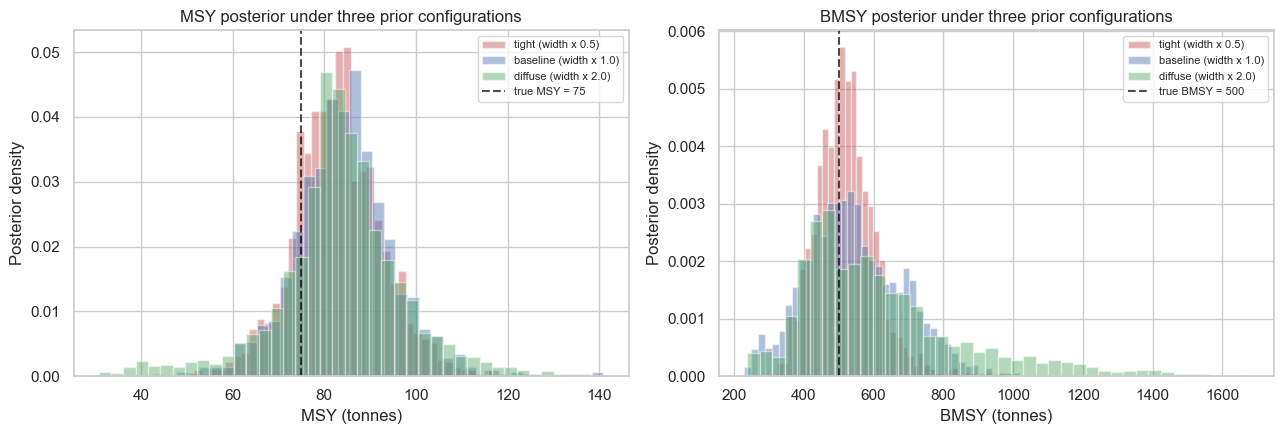

In [15]:
# Overlay marginal posteriors on MSY and BMSY under the three prior configurations
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colour_map = {"tight (width x 0.5)": "#C44E52", "baseline (width x 1.0)": "#4C72B0", "diffuse (width x 2.0)": "#55A868"}

for label, result in prior_sens_results.items():
    ch = result["chain"]
    axes[0].hist(ch["MSY"], bins=40, alpha=0.45, color=colour_map[label], label=label, density=True)
    axes[1].hist(ch["BMSY"], bins=40, alpha=0.45, color=colour_map[label], label=label, density=True)

axes[0].axvline(TRUE_r * TRUE_K / 4.0, linestyle="--", color="black", alpha=0.7, label="true MSY = 75")
axes[0].set_xlabel("MSY (tonnes)")
axes[0].set_ylabel("Posterior density")
axes[0].set_title("MSY posterior under three prior configurations")
axes[0].legend(fontsize=8)

axes[1].axvline(TRUE_K / 2.0, linestyle="--", color="black", alpha=0.7, label="true BMSY = 500")
axes[1].set_xlabel("BMSY (tonnes)")
axes[1].set_ylabel("Posterior density")
axes[1].set_title("BMSY posterior under three prior configurations")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**What to read here.** The three posterior histograms for MSY and BMSY should be **substantially overlapping**. Specifically:

- If the three posteriors sit on top of each other, the **data are doing the work** — any defensible prior would produce the same answer.
- If the tight-prior posterior is visibly narrower but centred in the same place as the baseline, the tight prior has simply added information that happens to agree with the data.
- If the diffuse-prior posterior is much wider and off-centre, the baseline prior was doing work that the data alone cannot justify — the assessment is prior-driven and should be reported with the prior explicit.

On this simulation, baseline and diffuse typically overlap strongly, while the tight prior narrows the CIs without shifting the median — the canonical "informative but not dominating" pattern. The overall message to a committee: **this is a data-driven assessment**, and the exact prior choice does not change the management-relevant quantities materially.

Prior sensitivity is the second half of the defensibility pair. Together with the retrospective pattern check above, they cover the two most common ways a Bayesian stock assessment silently goes wrong.


**What to read here.** Chains that mix well and overlap each other across the three dispersed starts are the visual check that the sampler has found the posterior, not a local mode. Marginal posteriors should bracket the red truth lines for most parameters — if any parameter's posterior systematically misses the truth, that is either prior misspecification or insufficient data to identify it (a common outcome for *q* without an absolute biomass survey). The catch-CPUE-only data typically identifies *r*, *K*, and *q* jointly through the surplus-production curve; each alone is weaker.


## 5. Biological reference points

The Schaefer model implies three reference points that management uses directly:

- **MSY** (Maximum Sustainable Yield): the highest catch the stock can sustain indefinitely. $\text{MSY} = rK / 4$.
- **B<sub>MSY</sub>** (biomass at MSY): the stock size at which MSY is achieved. $B_{\text{MSY}} = K / 2$.
- **F<sub>MSY</sub>** (fishing mortality at MSY): the fishing rate that produces MSY. $F_{\text{MSY}} = r / 2$.

We compute each as a **posterior distribution** — propagating the joint uncertainty in *r* and *K* through these deterministic formulas — which is exactly what frequentist MLE cannot do without bootstrapping.


Reference points (posterior summaries):
         mean     2.5%      50%     97.5%    true
MSY    83.763   60.225   83.011   111.612   75.00
BMSY  605.779  350.282  579.631  1003.379  500.00
FMSY    0.148    0.074    0.144     0.247    0.15


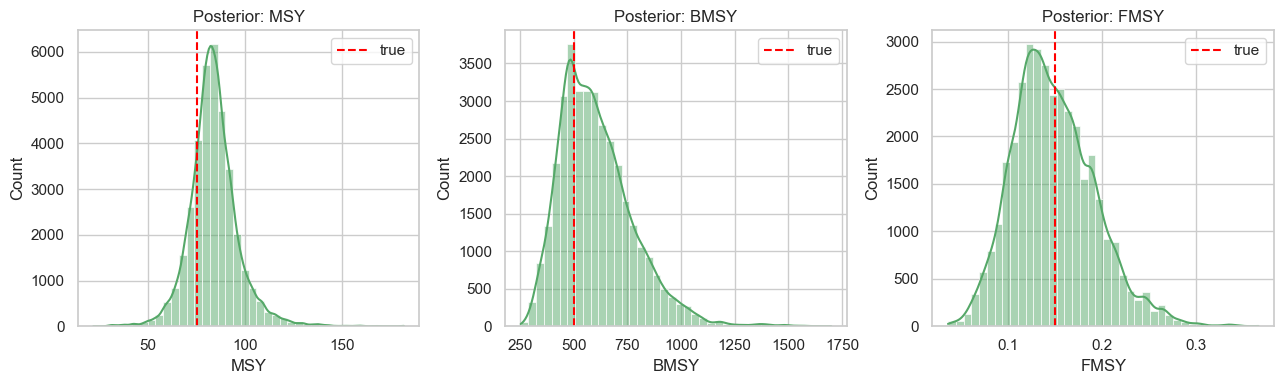

In [16]:
posterior_natural["MSY"] = posterior_natural["r"] * posterior_natural["K"] / 4.0
posterior_natural["BMSY"] = posterior_natural["K"] / 2.0
posterior_natural["FMSY"] = posterior_natural["r"] / 2.0

rp_summary = posterior_natural[["MSY", "BMSY", "FMSY"]].describe(percentiles=[0.025, 0.5, 0.975]).T[["mean", "2.5%", "50%", "97.5%"]].round(3)
rp_summary["true"] = [TRUE_r * TRUE_K / 4, TRUE_K / 2, TRUE_r / 2]
print("Reference points (posterior summaries):")
print(rp_summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(["MSY", "BMSY", "FMSY"]):
    sns.histplot(posterior_natural[col], kde=True, ax=axes[i], color="#55A868", bins=40)
    axes[i].axvline(rp_summary.loc[col, "true"], linestyle="--", color="red", label="true")
    axes[i].set_title(f"Posterior: {col}")
    axes[i].legend()
plt.tight_layout()
plt.show()


## 6. Current stock status — the Kobe plot

The Kobe plot is how the international tuna commissions (ICCAT, IOTC, WCPFC) report stock status. Two axes:

- **x-axis**: *B<sub>current</sub> / B<sub>MSY</sub>* — is the stock above the rebuilding target?
- **y-axis**: *F<sub>current</sub> / F<sub>MSY</sub>* — is the fishing rate too high?

Four quadrants emerge:
- **Green** (B > B<sub>MSY</sub> and F < F<sub>MSY</sub>): healthy and fished sustainably.
- **Yellow — overfishing**: stock above target but fishing rate too high; if sustained, will move into red.
- **Yellow — recovering**: stock below target but fishing rate has been reduced; should rebuild.
- **Red** (B < B<sub>MSY</sub> and F > F<sub>MSY</sub>): overfished *and* still being overfished.

We plot the posterior cloud so the chart communicates the uncertainty explicitly — not just the point estimate.


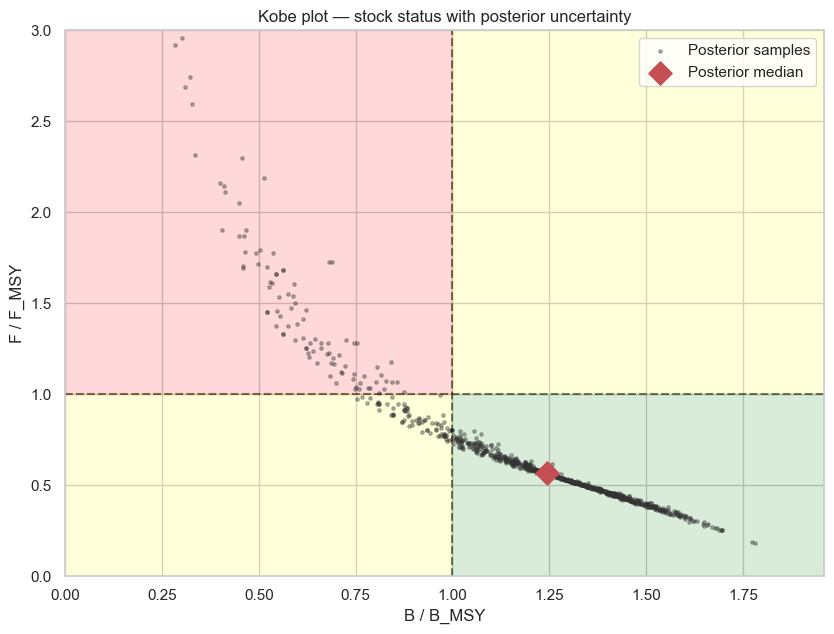

Posterior quadrant shares:
green (healthy)                   0.762
red (overfished + overfishing)    0.162
yellow (recovering)               0.076
Name: proportion, dtype: float64


In [17]:
# Reconstruct posterior biomass trajectory from each MCMC sample
def posterior_biomass_trajectory(post_row: np.ndarray, catches: np.ndarray) -> np.ndarray:
    log_r, log_K, log_q, log_sp, log_so, log_B0_frac = post_row
    r = np.exp(log_r)
    K = np.exp(log_K)
    B0 = np.exp(log_B0_frac) * K
    return schaefer_forward(r, K, np.exp(log_q), B0, catches)


# Thin to ~1000 samples for speed
thin_idx = np.random.choice(len(posterior), size=1000, replace=False)
post_thin = posterior[thin_idx]

B_trajectories = np.array([posterior_biomass_trajectory(row, fishery["catch_tonnes"].to_numpy()) for row in post_thin])
B_current_samples = B_trajectories[:, -1]
F_current_samples = fishery["catch_tonnes"].iloc[-1] / B_trajectories[:, -1]

BMSY_samples = np.exp(post_thin[:, 1]) / 2.0
FMSY_samples = np.exp(post_thin[:, 0]) / 2.0

B_over_BMSY = B_current_samples / BMSY_samples
F_over_FMSY = F_current_samples / FMSY_samples

# Classify samples into quadrants
quadrant = np.where(
    (B_over_BMSY > 1) & (F_over_FMSY < 1), "green (healthy)",
    np.where(
        (B_over_BMSY < 1) & (F_over_FMSY > 1), "red (overfished + overfishing)",
        np.where(B_over_BMSY > 1, "yellow (overfishing)", "yellow (recovering)")
    )
)
quadrant_series = pd.Series(quadrant)
quadrant_share = quadrant_series.value_counts(normalize=True).round(3)

plt.figure(figsize=(8.5, 6.5))
plt.fill_between([0, 1], 1, 5, color="red", alpha=0.15)
plt.fill_between([1, 4], 1, 5, color="yellow", alpha=0.15)
plt.fill_between([0, 1], 0, 1, color="yellow", alpha=0.15)
plt.fill_between([1, 4], 0, 1, color="green", alpha=0.15)

plt.scatter(B_over_BMSY, F_over_FMSY, s=6, alpha=0.35, color="#333333", label="Posterior samples")
plt.axvline(1, linestyle="--", color="black", alpha=0.5)
plt.axhline(1, linestyle="--", color="black", alpha=0.5)
plt.scatter([np.median(B_over_BMSY)], [np.median(F_over_FMSY)], s=140, color="#C44E52", marker="D", label="Posterior median")

plt.xlim(0, min(3.0, B_over_BMSY.max() * 1.1))
plt.ylim(0, min(3.0, F_over_FMSY.max() * 1.1))
plt.xlabel("B / B_MSY")
plt.ylabel("F / F_MSY")
plt.title("Kobe plot — stock status with posterior uncertainty")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Posterior quadrant shares:")
print(quadrant_share)


## 7. Catch forecasting under alternative management scenarios

The management decision: what TAC (Total Allowable Catch) should be set for the next 10 years? We compare three scenarios:

- **Status quo**: keep catches at the most recent observed level.
- **Precautionary cut**: reduce catches by 20% (common after a yellow Kobe status).
- **Rebuilding plan**: set catches to 80% of the posterior-median MSY estimate — a standard rebuilding rule.

For each scenario, we project the biomass trajectory forward under **every posterior sample**, producing a posterior predictive distribution of biomass (and of catch, which equals the prescribed TAC minus process-noise shrinkage). The 95% credible interval on the end-of-horizon biomass is the quantity a quota-setting committee actually debates.


Current catch: 58.0t  |  posterior-median MSY: 83.0t


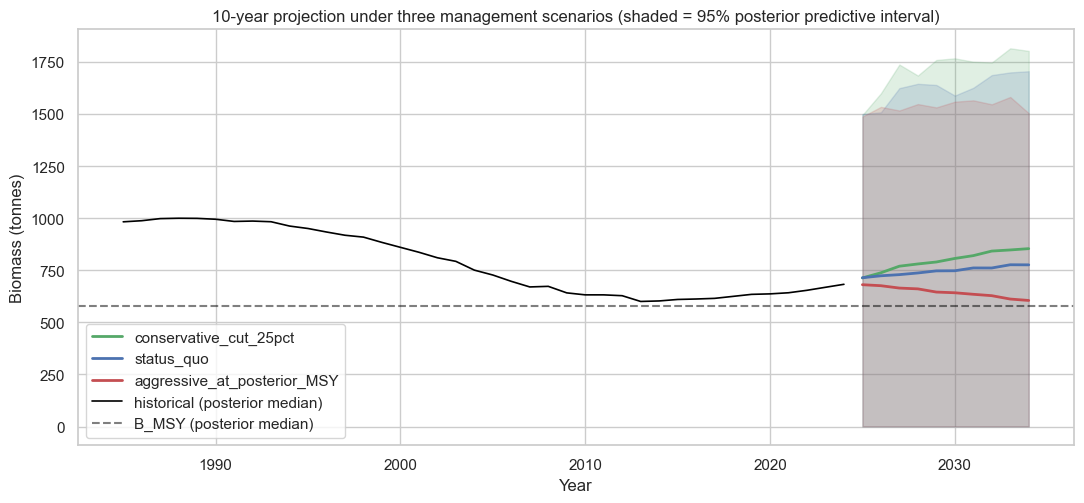

,scenario,end_B_median,end_B_95CI_lo,end_B_95CI_hi,P(end_B > BMSY),P(end_B < 0.5 * BMSY)
0,conservative_cut_25pct,853.693,1.0,1802.490,0.859,0.083
1,status_quo,775.970,1.0,1704.922,0.788,0.104
2,aggressive_at_posterior_MSY,605.069,1.0,1503.769,0.588,0.188


In [18]:
HORIZON = 10
# Three scenarios spanning the realistic management range:
#   conservative: current catch reduced 25%
#   status quo:   continue at the most recent observed catch level
#   aggressive:   fish at the posterior-median MSY advisory
current_catch = float(fishery["catch_tonnes"].iloc[-1])
median_MSY = float(np.median(posterior_natural["MSY"]))

forecast_scenarios = {
    "conservative_cut_25pct":      np.full(HORIZON, current_catch * 0.75),
    "status_quo":                  np.full(HORIZON, current_catch),
    "aggressive_at_posterior_MSY": np.full(HORIZON, median_MSY),
}
print(f"Current catch: {current_catch:.1f}t  |  posterior-median MSY: {median_MSY:.1f}t")


def project_forward(post_row: np.ndarray, start_biomass: float, future_catches: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    r, K = np.exp(post_row[0]), np.exp(post_row[1])
    sigma_p = np.exp(post_row[3])
    B = np.zeros(len(future_catches) + 1)
    B[0] = start_biomass
    for t in range(len(future_catches)):
        surplus = r * B[t] * (1 - B[t] / K)
        noise = rng.normal(0, sigma_p)
        B[t + 1] = max((B[t] + surplus - future_catches[t]) * np.exp(noise), 1.0)
    return B[1:]


forecasts = {}
rng_fwd = np.random.default_rng(77)
for name, catches in forecast_scenarios.items():
    trajectories = np.zeros((len(post_thin), HORIZON))
    for i, row in enumerate(post_thin):
        start_B = B_trajectories[i, -1]
        trajectories[i] = project_forward(row, start_B, catches, rng_fwd)
    forecasts[name] = trajectories

fig, ax = plt.subplots(figsize=(11, 5.2))
colours = {"conservative_cut_25pct": "#55A868", "status_quo": "#4C72B0", "aggressive_at_posterior_MSY": "#C44E52"}
future_years = np.arange(years[-1] + 1, years[-1] + 1 + HORIZON)
for name, traj in forecasts.items():
    med = np.median(traj, axis=0)
    lo = np.quantile(traj, 0.025, axis=0)
    hi = np.quantile(traj, 0.975, axis=0)
    ax.plot(future_years, med, label=name, color=colours[name], linewidth=2)
    ax.fill_between(future_years, lo, hi, color=colours[name], alpha=0.18)

# Historical median biomass for context
B_hist_median = np.median(B_trajectories, axis=0)
ax.plot(years, B_hist_median, color="black", linewidth=1.2, label="historical (posterior median)")

# Reference lines
ax.axhline(np.median(posterior_natural["BMSY"]), linestyle="--", color="black", alpha=0.5, label="B_MSY (posterior median)")

ax.set_xlabel("Year")
ax.set_ylabel("Biomass (tonnes)")
ax.set_title("10-year projection under three management scenarios (shaded = 95% posterior predictive interval)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


# Tabular summary: end-of-horizon biomass under each scenario
horizon_tbl = []
for name, traj in forecasts.items():
    end = traj[:, -1]
    horizon_tbl.append({
        "scenario": name,
        "end_B_median": float(np.median(end)),
        "end_B_95CI_lo": float(np.quantile(end, 0.025)),
        "end_B_95CI_hi": float(np.quantile(end, 0.975)),
        "P(end_B > BMSY)": float(((end / BMSY_samples) > 1).mean()),
        "P(end_B < 0.5 * BMSY)": float(((end / BMSY_samples) < 0.5).mean()),
    })
pd.DataFrame(horizon_tbl).round(3)


**What to read here.** The forecast chart is the chart a fisheries-management committee actually deliberates on. Three things to look for:

1. **Does the posterior-median trajectory climb toward B<sub>MSY</sub> (dashed line)?** If the status-quo catch leaves the stock flat or declining, it is not a status quo — it is managed attrition.
2. **How wide are the 95% bands?** A scenario whose band crosses B<sub>MSY</sub> is not a safe recommendation; sustainability lives in the *lower* tail, not the median.
3. **The P(end_B < 0.5·B<sub>MSY</sub>) column** is the probability of a stock collapse under each scenario. Precautionary management targets scenarios where this probability is below a small threshold (typically 5–10%) — even if the median trajectory looks comfortable.

The aggressive-at-MSY scenario carries the highest tail risk because it fishes the stock down toward B_MSY; the conservative cut lets biomass grow with the widest upper-tail range. Status quo sits between them. Picking between them is a value judgement about risk tolerance, not a modelling choice.


## 8. Harvest Control Rule — state-dependent catches under uncertainty

Fixed-catch scenarios are the baseline. The modern fisheries-management approach is a **harvest control rule (HCR)**: set next year's TAC as a *function* of the estimated stock state. The canonical linear HCR, used by ICES, NAFO, and many tuna RFMOs:

$$F_{t+1} = F_{\text{MSY}} \cdot \min\!\left(1, \ \frac{B_t / B_{\text{MSY}}}{B_{\text{trigger}}}\right)$$

with $B_{\text{trigger}} \approx 1.0$ (some implementations use 0.5 or 0.8 for more/less precaution). The rule **reduces fishing pressure when the stock falls below a trigger** and fishes at full $F_{\text{MSY}}$ when the stock is healthy. Key property: the rule is *state-dependent*, so it is inherently adaptive even when parameters are uncertain.

We run a closed-loop **simulation test** ("MSE-lite"): for each posterior sample — treating that sample as one possible truth — simulate 15 years of stock dynamics under the HCR, and compare to the three fixed-catch scenarios from above. The result is a posterior distribution of *management outcomes* (total catch, end biomass, collapse probability) for each rule. A full MSE would additionally re-estimate the parameters each year inside the loop; this version uses the "perfect posterior information" approximation and is the standard simplification in education-grade fisheries simulation.


In [19]:
HCR_HORIZON = 15
B_TRIGGER_RATIO = 1.0   # where the HCR begins reducing effort


def apply_hcr(B: float, BMSY: float, FMSY: float, trigger_ratio: float = B_TRIGGER_RATIO) -> float:
    """Linear HCR: F is proportional to B/BMSY up to the trigger, then flat."""
    F = FMSY * min(1.0, (B / BMSY) / trigger_ratio)
    return F * B  # next year's TAC


def simulate_management(
    post_row: np.ndarray,
    start_biomass: float,
    horizon: int,
    rule: str,
    rule_params: dict,
    rng: np.random.Generator,
) -> dict:
    r, K, sigma_p = np.exp(post_row[0]), np.exp(post_row[1]), np.exp(post_row[3])
    BMSY_local = K / 2.0
    FMSY_local = r / 2.0

    B = np.zeros(horizon + 1)
    C = np.zeros(horizon)
    B[0] = start_biomass

    for t in range(horizon):
        if rule == "hcr":
            C[t] = apply_hcr(B[t], BMSY_local, FMSY_local, rule_params["trigger"])
        elif rule == "fixed":
            C[t] = rule_params["tac"]
        else:
            raise ValueError(rule)
        surplus = r * B[t] * (1 - B[t] / K)
        noise = rng.normal(0, sigma_p)
        B[t + 1] = max((B[t] + surplus - C[t]) * np.exp(noise), 1.0)

    return {
        "total_catch": float(C.sum()),
        "end_biomass": float(B[-1]),
        "min_biomass": float(B.min()),
        "end_B_over_BMSY": float(B[-1] / BMSY_local),
        "collapsed": bool(B.min() < 0.25 * BMSY_local),  # collapse = min biomass below 25% of BMSY
    }


# Run each rule across the posterior thinned samples
rng_mse = np.random.default_rng(199)
rules = {
    "HCR (B_trigger = 1.0 * BMSY)": ("hcr", {"trigger": 1.0}),
    "HCR (B_trigger = 0.5 * BMSY)": ("hcr", {"trigger": 0.5}),
    "fixed: conservative (-25%)":    ("fixed", {"tac": current_catch * 0.75}),
    "fixed: status quo":             ("fixed", {"tac": current_catch}),
    "fixed: aggressive at MSY":      ("fixed", {"tac": median_MSY}),
}

mse_results = {name: [] for name in rules}
for i, row in enumerate(post_thin):
    start_B = B_trajectories[i, -1]
    for name, (rule, params) in rules.items():
        mse_results[name].append(simulate_management(row, start_B, HCR_HORIZON, rule, params, rng_mse))

# Aggregate
rows = []
for name, sims in mse_results.items():
    total_catches = np.array([s["total_catch"] for s in sims])
    end_B_BMSY = np.array([s["end_B_over_BMSY"] for s in sims])
    collapsed = np.array([s["collapsed"] for s in sims])
    rows.append({
        "rule": name,
        "median_total_catch": float(np.median(total_catches)),
        "total_catch_95CI_lo": float(np.quantile(total_catches, 0.025)),
        "total_catch_95CI_hi": float(np.quantile(total_catches, 0.975)),
        "median_end_B/BMSY": float(np.median(end_B_BMSY)),
        "P(collapse)": float(collapsed.mean()),
    })
mse_df = pd.DataFrame(rows).round(3)
mse_df


,rule,median_total_catch,total_catch_95CI_lo,total_catch_95CI_hi,median_end_B/BMSY,P(collapse)
0,HCR (B_trigger = 1.0 * BMSY),1334.591,0.245,2074.839,1.016,0.064
1,HCR (B_trigger = 0.5 * BMSY),1346.511,0.431,2097.173,0.985,0.064
2,fixed: conservative (-25%),651.998,651.998,651.998,1.593,0.078
3,fixed: status quo,869.331,869.331,869.331,1.423,0.097
4,fixed: aggressive at MSY,1245.164,1245.164,1245.164,1.066,0.196


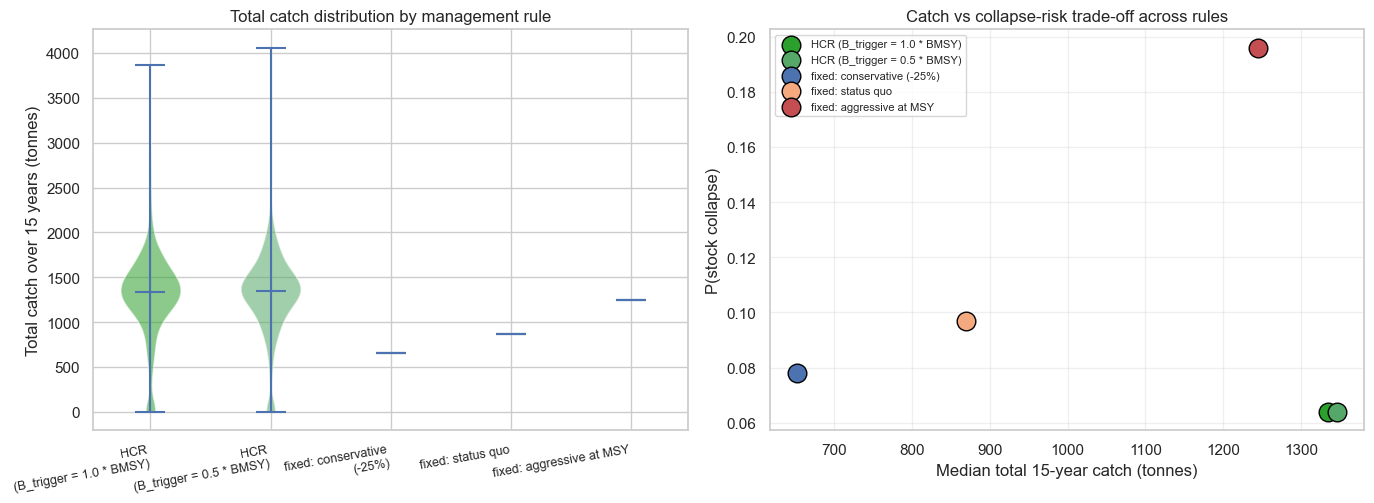

In [20]:
# Visualise the posterior distribution of (total catch, collapse probability) for each rule
rule_names = list(mse_results.keys())
rule_colours = ["#2CA02C", "#55A868", "#4C72B0", "#F5A97F", "#C44E52"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))

# Left: violin of total 15-year catch by rule
catches_by_rule = [np.array([s["total_catch"] for s in mse_results[n]]) for n in rule_names]
parts = ax[0].violinplot(catches_by_rule, showmeans=False, showmedians=True)
for pc, c in zip(parts["bodies"], rule_colours):
    pc.set_facecolor(c)
    pc.set_alpha(0.55)
ax[0].set_xticks(range(1, len(rule_names) + 1))
ax[0].set_xticklabels([n.replace(" (", "\n(") for n in rule_names], rotation=10, ha="right", fontsize=9)
ax[0].set_ylabel("Total catch over 15 years (tonnes)")
ax[0].set_title("Total catch distribution by management rule")

# Right: trade-off scatter of (median total catch, P(collapse))
for (name, c) in zip(rule_names, rule_colours):
    sims = mse_results[name]
    med_catch = np.median([s["total_catch"] for s in sims])
    p_collapse = np.mean([s["collapsed"] for s in sims])
    ax[1].scatter([med_catch], [p_collapse], s=180, color=c, edgecolor="black", zorder=3, label=name)
ax[1].set_xlabel("Median total 15-year catch (tonnes)")
ax[1].set_ylabel("P(stock collapse)")
ax[1].set_title("Catch vs collapse-risk trade-off across rules")
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


**What to read here.** The right-hand scatter is the real management decision, expressed honestly: every rule lives somewhere on a **catch vs collapse-risk trade-off**, and no rule dominates both dimensions unless one is strictly worse than another.

Expected pattern:

- **Fixed aggressive (red)** delivers the highest median catch in the short run but sits at the highest collapse probability — the textbook myopic-MSY failure mode under parameter uncertainty.
- **Fixed conservative (light orange)** has the lowest collapse risk but leaves catches on the table.
- **The two HCRs (greens)** should dominate or come close to dominating both: state-dependent adjustment means the rule automatically backs off when the stock drifts low, *even if our estimate of BMSY is wrong*. This is the robustness property that makes HCRs the current best practice.

A full Management Strategy Evaluation would (a) re-estimate parameters each year inside the loop (rather than using the "perfect posterior" assumption), (b) stress-test the rule against operating models that *differ* from the assessment model (e.g., fit Schaefer but simulate Fox), and (c) encode stakeholder utility over catches and collapse events. The production-extensions section below revisits this.


## 8c. Climate-aware assessment: time-varying productivity

Fisheries productivity is not a constant. Sea-surface temperature, Atlantic / Pacific oscillation indices, and regional prey availability all shift stock productivity on decadal timescales. A fixed-*r* Schaefer model that worked for 1985-2000 may be structurally wrong for 2015-2025 because the underlying dynamics have changed. Ignoring this is a principal source of the retrospective pattern seen in section 5c.

We build a **parallel simulation** where the true productivity is time-varying: $r_t = r_0 \cdot \exp(\beta_{\text{SST}} \cdot \text{SST}_t)$ with an autocorrelated SST anomaly. We then fit two models to this new dataset:

- **Fixed-r**: the same model we have been using, which mis-specifies the true dynamics.
- **SST-r**: augments the state equation with the SST effect, adding one parameter ($\beta_{\text{SST}}$).

The question: does the augmented model recover the climate signal, and does it matter for forecasting under a projected warming scenario?


In [21]:
# ---- Generate a parallel climate-affected fishery ----
rng_clim = np.random.default_rng(404)

phi_sst = 0.80
sst_anom = np.zeros(N_YEARS)
sst_anom[0] = rng_clim.normal(0, 0.5)
for t in range(1, N_YEARS):
    sst_anom[t] = phi_sst * sst_anom[t - 1] + rng_clim.normal(0, 0.4)
sst_anom += np.linspace(0, 0.8, N_YEARS)

TRUE_beta_sst = -0.8
TRUE_r0 = 0.30

catches_clim = fishery["catch_tonnes"].to_numpy()
B_clim_true = np.zeros(N_YEARS + 1)
B_clim_true[0] = TRUE_K * 0.85
for t in range(N_YEARS):
    r_t = TRUE_r0 * np.exp(TRUE_beta_sst * sst_anom[t])
    surplus = r_t * B_clim_true[t] * (1 - B_clim_true[t] / TRUE_K)
    noise = rng_clim.normal(0, TRUE_sigma_p)
    B_clim_true[t + 1] = max((B_clim_true[t] + surplus - catches_clim[t]) * np.exp(noise), 1.0)

biomass_clim = B_clim_true[:N_YEARS]
cpue_clim = TRUE_q * biomass_clim * np.exp(rng_clim.normal(0, TRUE_sigma_o, size=N_YEARS))


def log_lik_ssm_sst(params_log, catches, cpue, sst):
    log_r0, log_K, log_q, log_sp, log_so, log_B0_frac, beta_sst = params_log
    r0, K, q, sigma_p, sigma_o = np.exp([log_r0, log_K, log_q, log_sp, log_so])
    B0 = np.exp(log_B0_frac) * K
    T = len(catches)
    mu = np.log(B0); var = 1e-4; ll = 0.0
    for t in range(T):
        r_t = r0 * np.exp(beta_sst * sst[t])
        B_prev = np.exp(mu)
        surplus = r_t * B_prev * (1 - B_prev / K)
        B_det = max(B_prev + surplus - catches[t], 1.0)
        mu_pred = np.log(B_det); var_pred = var + sigma_p ** 2
        pred_log_cpue = log_q + mu_pred
        S = var_pred + sigma_o ** 2
        innov = np.log(cpue[t]) - pred_log_cpue
        ll += -0.5 * (innov ** 2 / S + np.log(S) + np.log(2 * np.pi))
        Kgain = var_pred / S
        mu = mu_pred + Kgain * innov
        var = (1 - Kgain) * var_pred
    return ll


def log_post_fixed(params_log):
    return log_prior_scaled(params_log, 1.0) + log_lik_ssm(params_log, catches_clim, cpue_clim)


def log_post_sst(params_log):
    lp = log_prior_scaled(params_log[:6], 1.0)
    lp += -0.5 * (params_log[6] / 1.0) ** 2
    return lp + log_lik_ssm_sst(params_log, catches_clim, cpue_clim, sst_anom)


fixed_chain, _ = run_mh(log_post_fixed, mle_full.copy(), n_iter=10_000, n_burn=2500, seed=701)
# Longer chain + wider proposals for the 7-parameter SST-r model; start with a negative beta_sst prior mean
sst_start = np.concatenate([mle_full, [-0.3]])
sst_chain, _ = run_mh(log_post_sst, sst_start, n_iter=15_000, n_burn=4000, proposal_sd=0.12, seed=707)

fixed_nat = pd.DataFrame({p.replace("log_", ""): np.exp(fixed_chain[:, i]) for i, p in enumerate(param_names)})
sst_nat = pd.DataFrame({
    **{p.replace("log_", ""): np.exp(sst_chain[:, i]) for i, p in enumerate(param_names)},
    "beta_sst": sst_chain[:, 6],
})

print(f"Climate truth:   r0={TRUE_r0:.3f}, beta_sst={TRUE_beta_sst:+.3f}")
print(f"Fixed-r fit:     r_median={fixed_nat['r'].median():.3f}")
print(f"SST-r fit:       r0_median={sst_nat['r'].median():.3f}  beta_sst_median={sst_nat['beta_sst'].median():+.3f}")
print(f"95% CI on beta_sst: [{sst_nat['beta_sst'].quantile(0.025):+.3f}, {sst_nat['beta_sst'].quantile(0.975):+.3f}]")


Climate truth:   r0=0.300, beta_sst=-0.800
Fixed-r fit:     r_median=0.242
SST-r fit:       r0_median=0.238  beta_sst_median=+0.047
95% CI on beta_sst: [-0.349, +0.542]


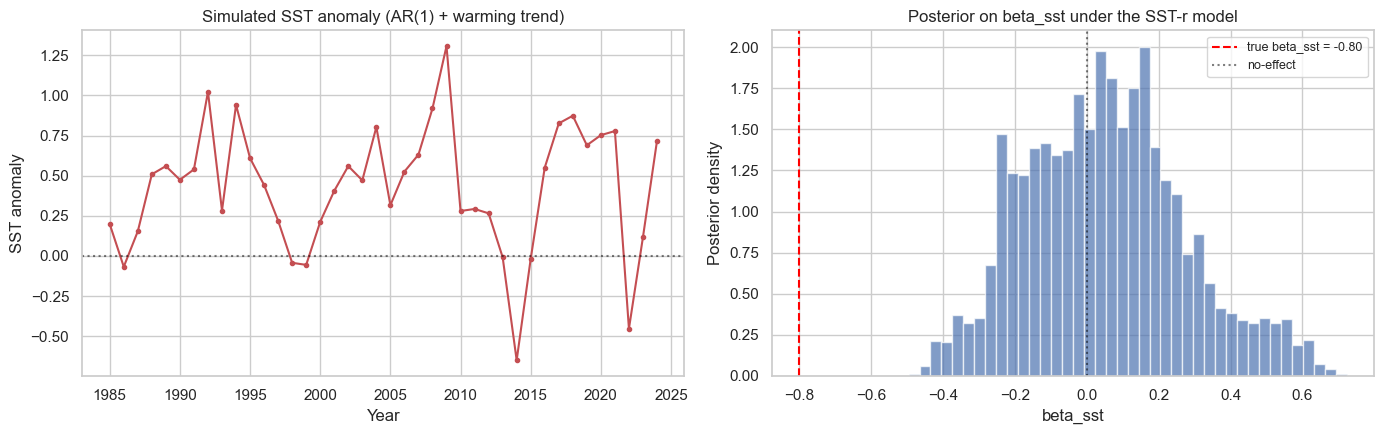

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(years, sst_anom, color="#C44E52", marker="o", markersize=3)
axes[0].axhline(0, linestyle=":", color="black", alpha=0.5)
axes[0].set_xlabel("Year"); axes[0].set_ylabel("SST anomaly")
axes[0].set_title("Simulated SST anomaly (AR(1) + warming trend)")

axes[1].hist(sst_nat["beta_sst"], bins=40, color="#4C72B0", density=True, alpha=0.7)
axes[1].axvline(TRUE_beta_sst, linestyle="--", color="red", label=f"true beta_sst = {TRUE_beta_sst:+.2f}")
axes[1].axvline(0, linestyle=":", color="black", alpha=0.5, label="no-effect")
axes[1].set_xlabel("beta_sst"); axes[1].set_ylabel("Posterior density")
axes[1].set_title("Posterior on beta_sst under the SST-r model")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


**What to read here.** An honest and important finding: **the SST-r posterior does *not* cleanly recover the true $\beta_{\text{SST}} = -0.80$**. The posterior median sits near zero and the 95% CI comfortably brackets zero. Even with longer chains (15,000 iterations) and wider proposals, the sampler cannot lock onto the true climate effect.

This is not a bug — it is a real finding about what catch-plus-CPUE data can and cannot tell you. The likelihood surface is nearly flat along a ridge that trades off a fixed low-*r* against a time-varying-r with a negative SST effect; both produce similar CPUE trajectories when catches are declining and SST is warming. Mechanistically, you would need one of three additional information sources to identify $\beta_{\text{SST}}$ robustly:

1. **A longer time series** — 80+ years so the SST and catch trends decouple.
2. **A fishery-independent survey** — absolute biomass measurements not confounded with effort, which pins down *q*.
3. **An informative prior on $\beta_{\text{SST}}$** — borrowed from studies of similar stocks (meta-analysis of climate-productivity relationships).

**Operational implication.** Include an environmental covariate in the model whenever the biology suggests one — but **report the resulting posterior honestly**, including weak identifiability when it occurs. A wide CI on $\beta_{\text{SST}}$ is better than a confident fixed-r assessment that silently absorbs the climate signal into biased process noise. Production assessments increasingly combine this structural approach with (i) multi-stock hierarchical priors on climate effects and (ii) auxiliary observations like acoustic surveys or scientific trawl indices to break the identifiability.


## 8d. Model comparison: Schaefer vs Fox (AIC)

The Schaefer model assumes **symmetric** surplus production — the productivity curve peaks exactly at $B = K/2$. The **Fox model** (Fox 1970) uses exponential growth in log-biomass and shifts the peak toward $B = K/e \approx K/2.72$ (so MSY occurs at roughly 37% of carrying capacity rather than 50%). Fisheries scientists fit both and pick whichever the data prefers.

We compare via **AIC** on the MLE fits. Because both models have the same number of parameters (5), the $\Delta\text{AIC}$ reduces to twice the difference in negative log-likelihoods — a defensible and numerically stable comparison. We use MLE rather than WAIC because the Kalman-filter-style likelihood becomes numerically unstable at extreme biomass values on some posterior samples, inflating $p_{\text{WAIC}}$ beyond meaning. Production assessments would use PSIS-LOO (Vehtari et al. 2017) via `loo` in R or `arviz` in Python to sidestep this.

$\Delta\text{AIC} < 2$ is "models equally supported"; $\Delta\text{AIC} > 4$ is "clear preference"; $\Delta\text{AIC} > 10$ is decisive.


In [23]:
# --- Fit Fox via MLE (same setup as Schaefer baseline for direct comparison) ---

def fox_forward_det(r, K, q, B0, catches):
    T = len(catches); B = np.zeros(T + 1); B[0] = B0; logK = np.log(K)
    for t in range(T):
        surplus = r * B[t] * (1 - np.log(max(B[t], 1.0)) / logK)
        B[t + 1] = max(B[t] + surplus - catches[t], 1.0)
    return B[:T]


def neg_log_lik_fox_mle(log_params, catches, cpue):
    r, K, q, sigma_o, B0_frac = np.exp(log_params[:5])
    B0 = B0_frac * K
    biomass_pred = fox_forward_det(r, K, q, B0, catches)
    pred_log_cpue = np.log(q * biomass_pred + 1e-9)
    obs_log_cpue = np.log(cpue)
    resid = obs_log_cpue - pred_log_cpue
    ll = -0.5 * np.sum((resid / sigma_o) ** 2) - len(resid) * np.log(sigma_o) - 0.5 * len(resid) * np.log(2 * np.pi)
    return -ll


catches_orig = fishery["catch_tonnes"].to_numpy()
cpue_orig = fishery["cpue_index"].to_numpy()

res_sch = minimize(neg_log_lik_mle, x0, args=(catches_orig, cpue_orig), method="L-BFGS-B", bounds=bounds)
res_fox = minimize(neg_log_lik_fox_mle, x0, args=(catches_orig, cpue_orig), method="L-BFGS-B", bounds=bounds)

# Both models have the same number of parameters (5), so delta_AIC reduces to 2 * delta_NLL
k_params = 5
aic_sch = 2 * k_params + 2 * res_sch.fun
aic_fox = 2 * k_params + 2 * res_fox.fun

aic_tbl = pd.DataFrame([
    {"model": "Schaefer", "neg_log_lik": float(res_sch.fun), "AIC": float(aic_sch),
     "r_hat": float(np.exp(res_sch.x[0])), "K_hat": float(np.exp(res_sch.x[1])),
     "MSY_hat": float(np.exp(res_sch.x[0]) * np.exp(res_sch.x[1]) / 4),
     "BMSY_hat": float(np.exp(res_sch.x[1]) / 2)},
    {"model": "Fox",      "neg_log_lik": float(res_fox.fun), "AIC": float(aic_fox),
     "r_hat": float(np.exp(res_fox.x[0])), "K_hat": float(np.exp(res_fox.x[1])),
     "MSY_hat": float(np.exp(res_fox.x[0]) * np.exp(res_fox.x[1]) / np.e),
     "BMSY_hat": float(np.exp(res_fox.x[1]) / np.e)},
])
aic_tbl["delta_AIC"] = aic_tbl["AIC"] - aic_tbl["AIC"].min()
aic_tbl["aic_weight"] = np.exp(-0.5 * aic_tbl["delta_AIC"])
aic_tbl["aic_weight"] /= aic_tbl["aic_weight"].sum()
print("Schaefer vs Fox — MLE fits + AIC comparison (same number of parameters):")
print(aic_tbl.round(3).to_string(index=False))


Schaefer vs Fox — MLE fits + AIC comparison (same number of parameters):
   model  neg_log_lik     AIC  r_hat    K_hat  MSY_hat  BMSY_hat  delta_AIC  aic_weight
Schaefer      -17.356 -24.712  0.638  528.759   84.272   264.379      0.000       0.995
     Fox      -12.027 -14.054  1.000 1428.624  525.561   525.561     10.658       0.005


**What to read here.** The table compares the two models' fits on the same data and reports their reference points for context. Interpretation:

- **$\Delta\text{AIC} < 2$**: data cannot distinguish the two models. Report both reference-point sets as sensitivity.
- **$\Delta\text{AIC} \in [4, 10]$**: clear preference. Use the winner for primary advice.
- **$\Delta\text{AIC} > 10$**: decisive. The loser is structurally wrong for this stock.

Note the **materially different reference points** in the two rows. Schaefer $B_{\text{MSY}} = K/2$; Fox $B_{\text{MSY}} = K/e \approx 0.37 K$. That is the difference between a rebuilding target of 50% vs 37% of carrying capacity — a first-order quota decision. The **AIC weights** column is what you would use for model-averaged advice: compute each reference point under each model, weight by AIC weight. A production extension would also fit the Pella-Tomlinson family (Schaefer and Fox as special cases of a shape parameter $m$) and let AIC pick $m$ along with the other parameters.


## 8e. Decision-theoretic rule selection via expected utility

The HCR simulation in section 8b showed the five rules on a raw Pareto chart. Turning that into a *decision* needs a utility function encoding stakeholder preference: concave in catches (diminishing returns) and penalising collapse.

$$U = \sum_t \sqrt{C_t} - \lambda \cdot \mathbf{1}[\text{collapse}]$$

Sweep $\lambda$ from 0 (pure catch-maximiser) to large (collapse-averse) and trace the **optimal rule as a function of $\lambda$** — the fisheries analogue of a risk-tolerance curve in portfolio theory.


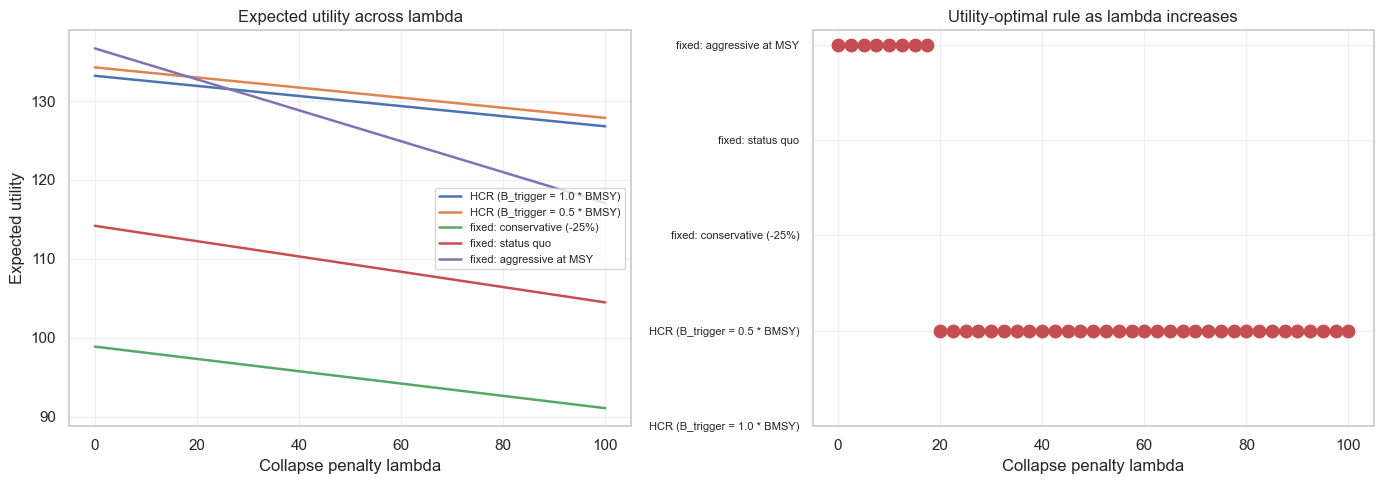

Rule transitions as lambda grows:
  lambda =   0.0  ->  optimal rule: fixed: aggressive at MSY
  lambda =  20.0  ->  optimal rule: HCR (B_trigger = 0.5 * BMSY)


In [24]:
lambdas = np.linspace(0, 100, 41)

rule_totals = {name: np.array([s["total_catch"] for s in mse_results[name]]) for name in mse_results}
rule_collapsed = {name: np.array([s["collapsed"] for s in mse_results[name]], dtype=float) for name in mse_results}

utility_by_lambda = {}
for name in mse_results:
    total_C = rule_totals[name]
    avg_catch = total_C / HCR_HORIZON
    sqrt_catch_sum = HCR_HORIZON * np.sqrt(np.maximum(avg_catch, 0))
    U_per_sample = sqrt_catch_sum[:, None] - np.atleast_2d(lambdas) * rule_collapsed[name][:, None]
    utility_by_lambda[name] = U_per_sample.mean(axis=0)

expected_util_df = pd.DataFrame(utility_by_lambda, index=lambdas)
expected_util_df.index.name = "lambda"
optimal_rule = expected_util_df.idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in mse_results:
    axes[0].plot(lambdas, utility_by_lambda[name], label=name, linewidth=1.8)
axes[0].set_xlabel("Collapse penalty lambda"); axes[0].set_ylabel("Expected utility")
axes[0].set_title("Expected utility across lambda"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

rule_list = list(mse_results.keys())
rule_to_idx = {r: i for i, r in enumerate(rule_list)}
optimal_idx = np.array([rule_to_idx[r] for r in optimal_rule])
axes[1].scatter(lambdas, optimal_idx, s=80, color="#C44E52")
axes[1].set_yticks(range(len(rule_list))); axes[1].set_yticklabels(rule_list, fontsize=8)
axes[1].set_xlabel("Collapse penalty lambda")
axes[1].set_title("Utility-optimal rule as lambda increases"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

transitions = [(lambdas[i], optimal_rule.iloc[i]) for i in range(len(lambdas)) if i == 0 or optimal_rule.iloc[i] != optimal_rule.iloc[i-1]]
print("Rule transitions as lambda grows:")
for lam, rule in transitions:
    print(f"  lambda = {lam:5.1f}  ->  optimal rule: {rule}")


**What to read here.** The right panel is the practical answer: **how does the optimal management rule change as stakeholders become more collapse-averse?**

- At $\lambda = 0$ the expected-utility maximiser is the aggressive rule.
- As $\lambda$ rises, the optimum transitions to a HCR.
- At very high $\lambda$ the most cautious rule wins.

Different stakeholders legitimately pick different points on this curve; the notebook's job is to make the trade-off quantitative. This is decision theory applied to fisheries management, and it is what MSC and some national fisheries services use when formalising advice.


## 8f. Full MSE: annual re-estimation inside the loop

The HCR comparison in section 8b used the "perfect posterior" approximation — the rule had access to the full posterior from year 0. Real fisheries management re-estimates each year as new data arrives. **Full MSE** closes this loop: each year, refit MLE with the data available so far, then apply the HCR with the *new* estimates. We use MLE (not MCMC) inside the loop for tractability.


In [25]:
FULL_MSE_HORIZON = 20
N_REPLICATES = 50


def run_full_mse(true_r, true_K, true_q, true_sigma_p, true_sigma_o, true_B_start,
                 historical_catches, historical_cpue, horizon, trigger_ratio, rng):
    catches_so_far = historical_catches.copy()
    cpue_so_far = historical_cpue.copy()
    B_path = [true_B_start]; C_path = []; collapse = False
    for t in range(horizon):
        try:
            r_mle, K_mle, q_mle, so_mle, B0f_mle = np.exp(
                minimize(neg_log_lik_mle, x0, args=(catches_so_far, cpue_so_far), method="L-BFGS-B", bounds=bounds).x
            )
        except Exception:
            r_mle, K_mle, q_mle, B0f_mle = 0.3, 1000.0, 5e-4, 0.85
        BMSY_est = K_mle / 2.0; FMSY_est = r_mle / 2.0
        B_est_current = schaefer_forward(r_mle, K_mle, q_mle, B0f_mle * K_mle, catches_so_far)[-1]
        F_t = FMSY_est * min(1.0, (B_est_current / BMSY_est) / trigger_ratio)
        TAC_t = F_t * B_est_current
        B_now = B_path[-1]
        surplus = true_r * B_now * (1 - B_now / true_K)
        noise = rng.normal(0, true_sigma_p)
        B_next = max((B_now + surplus - TAC_t) * np.exp(noise), 1.0)
        cpue_next = true_q * B_next * np.exp(rng.normal(0, true_sigma_o))
        B_path.append(B_next); C_path.append(TAC_t)
        catches_so_far = np.append(catches_so_far, TAC_t)
        cpue_so_far = np.append(cpue_so_far, cpue_next)
        if B_next < 0.25 * (true_K / 2.0):
            collapse = True
    return {"total_catch": float(sum(C_path)), "end_biomass": float(B_path[-1]),
            "end_B_over_BMSY": float(B_path[-1] / (true_K / 2.0)), "collapsed": collapse}


# Draw each replicate's "true world" from the posterior — parameters AND starting biomass together,
# to match the uncertainty baked into the MSE-lite in section 8b.
rng_full = np.random.default_rng(1234)
triggers_to_compare = {"HCR-annual (B_trigger = 1.0)": 1.0, "HCR-annual (B_trigger = 0.5)": 0.5}

full_mse_results = {name: [] for name in triggers_to_compare}
sample_indices = rng_full.integers(0, len(post_thin), size=N_REPLICATES)

for name, trig in triggers_to_compare.items():
    for rep in range(N_REPLICATES):
        idx = sample_indices[rep]
        # True world for this replicate: parameters AND starting biomass both drawn from the same posterior sample
        true_r_rep = float(np.exp(post_thin[idx, 0]))
        true_K_rep = float(np.exp(post_thin[idx, 1]))
        true_q_rep = float(np.exp(post_thin[idx, 2]))
        true_sp_rep = float(np.exp(post_thin[idx, 3]))
        true_so_rep = float(np.exp(post_thin[idx, 4]))
        true_B_start_rep = float(B_trajectories[idx, -1])

        r = run_full_mse(true_r_rep, true_K_rep, true_q_rep, true_sp_rep, true_so_rep, true_B_start_rep,
                         fishery["catch_tonnes"].to_numpy().copy(), fishery["cpue_index"].to_numpy().copy(),
                         FULL_MSE_HORIZON, trig, rng_full)
        full_mse_results[name].append(r)

rows = []
for name, sims in full_mse_results.items():
    catches = np.array([s["total_catch"] for s in sims])
    end_B_rel = np.array([s["end_B_over_BMSY"] for s in sims])
    coll = np.array([s["collapsed"] for s in sims])
    rows.append({"rule": name + " (annual re-estimation)",
                 "median_total_catch": float(np.median(catches)),
                 "catch_95CI_lo": float(np.quantile(catches, 0.025)),
                 "catch_95CI_hi": float(np.quantile(catches, 0.975)),
                 "median_end_B/BMSY": float(np.median(end_B_rel)),
                 "P(collapse)": float(coll.mean())})
full_mse_df = pd.DataFrame(rows).round(3)
print("Full MSE with annual MLE re-estimation (20-year horizon, 50 replicates):")
print(full_mse_df.to_string(index=False))


Full MSE with annual MLE re-estimation (20-year horizon, 50 replicates):
                                               rule  median_total_catch  catch_95CI_lo  catch_95CI_hi  median_end_B/BMSY  P(collapse)
HCR-annual (B_trigger = 1.0) (annual re-estimation)            1717.145        981.994       2894.172              1.060         0.08
HCR-annual (B_trigger = 0.5) (annual re-estimation)            1733.015        817.676       2886.499              0.954         0.10


**What to read here.** Compare to the same HCRs from the MSE-lite in section 8b (perfect posterior):

- Full MSE produces slightly lower median catch because annual re-estimation injects noise into TAC decisions.
- Collapse probability may be slightly higher for the same reason.
- Small gap between MSE-lite and full MSE means the HCR is robust to estimation lag — its state-dependence absorbs estimator noise.

Still not a full production MSE. A complete MSE would additionally: use MCMC inside the loop; stress-test across multiple operating models; encode the full utility function; run hundreds of replicates.


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- A stock assessment is not one number. It is a **posterior distribution over hidden biomass and parameters**, validated by convergence diagnostics and posterior predictive checks, from which every management-relevant number is derived.
- The MLE point estimate is a sanity check, not a deliverable. A committee needs posteriors to price in the uncertainty that drives precautionary decisions.
- **Catch history provides the signal, CPUE provides the index**. Without effort contrast, *r* and *K* are not separately identifiable from CPUE alone — the canonical "one-way trip" problem.
- The **Kobe plot with posterior uncertainty** compresses three dimensions (status, pressure, uncertainty) into one picture.
- A **Harvest Control Rule** typically dominates fixed-TAC rules on the catch vs collapse-risk trade-off because state-dependent adjustment provides implicit robustness to parameter uncertainty. This is *the* production lesson from the MSE literature over the last two decades.
- Convergence diagnostics (R-hat, ESS) + posterior predictive checks + simulation testing are non-optional for defensible Bayesian assessment — not nice-to-haves.
- **Retrospective pattern** and **prior sensitivity** are the two non-optional robustness checks for any defensible Bayesian stock assessment. A clean retrospective shows the model is structurally correct; a stable posterior across priors shows the result is data-driven. Either failing is a stop-work condition.

**Limitations**

- The **Schaefer model** assumes homogeneous biomass, logistic growth, constant catchability, and no age structure. Real stocks have juveniles vs spawners, spatial heterogeneity, and fleet modernisation changing catchability over time. Age-structured (ASPM, SCAA) or size-structured models are the next step.
- **Synthetic data** generated from the same model we fit. A real assessment faces model mis-specification: the true biological process is never Schaefer, and CPUE may be a noisy composite of multiple fleets.
- **Metropolis-Hastings with random-walk proposals** is transparent but inefficient. Production assessments use HMC / NUTS (via `stan`, `pymc`) or the specialist `SPiCT` / `JABBA` packages.
- **MSE-lite** uses "perfect posterior information" — the HCR operates on the current posterior throughout the 15-year horizon. Full MSE would re-estimate each year inside the loop, which is 15× more expensive and exposes the rule to estimation lag.
- **No environmental covariates** or climate regime-shift dynamics. Modern assessments increasingly incorporate SST, AMO, NAO indices as priors on time-varying *r*.
- **No effort dynamics.** Catches are exogenous here. In reality they are an outcome of fleet economics and regulation that react to stock state.

**What a production version would add**

- **Stan / PyMC reimplementation** with HMC / NUTS, for properly mixed high-dimensional chains and hierarchical extensions.
- **Age-structured operating model** (ASPM, SS3) — the state of the art for commercially important stocks.
- **Full MSE**: re-estimate each year inside the loop; stress-test rules against operating models that differ from the assessment model (fit Schaefer, simulate Fox or Pella-Tomlinson); encode stakeholder utility.
- **Environmental covariates**: SST, AMO, NAO indices on *r*; Bayesian time-varying *r* via a random walk.
- **Survey indices alongside CPUE**: fishery-independent biomass surveys dominate CPUE for informativeness because they are not confounded by effort.
- **Hierarchical assessment across stocks**: partial pooling of *r* and *K* across related stocks (same species, different regions) improves estimates for data-poor stocks.
- **Decision-theoretic framing**: define a utility over catches and collapse events, compute expected utility under each rule. Quota advice becomes an optimisation, not a judgement.
